## 📈 🔎 Analysis and Plotting 🔎 📈

This notebook provides the workflow for reproducing the analysis and plots in Kennison et al. (in prep). Additional relevant files can be found in the Files folder of the repository. 

For more on data access with IPFS, see https://orcestra-campaign.org/data.html. 
SEA-POL data is available through IPFS on the ORCESTRA data browser at https://browser.orcestra-campaign.org/#/?s=.

## ⬇️ Import relevant libraries and SEA-POL data. 

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import numpy.ma as ma
from matplotlib import rc, colors, ticker
import matplotlib.dates as mdates
import subprocess, cmocean
import xarray as xr
import pandas as pd
import metpy
from metpy.units import units
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats
import netCDF4 as nc
from datetime import timedelta
import subprocess, cmocean
from scipy.optimize import curve_fit
import cmweather
import cmocean
from datetime import datetime
from scipy.stats import norm
from scipy.ndimage import gaussian_filter, label, generate_binary_structure 
import random 
import matplotlib.colors as mcolors 

In [53]:
# Access the PICCOLO_level4_rainrate_2D.zarr dataset at the following URL:
url = "http://127.0.0.1:8080/ipns/latest.orcestra-campaign.org/products/METEOR/SEA-POL/PICCOLO_level4_rainrate_2D.zarr/"

# Open the 2D dataset using xarray with the zarr engine. 
ds = xr.open_dataset(url, engine="zarr")
vars_list = list(ds.variables.keys())

# Print a list of available variables in the dataset.
print(vars_list)

['DBZ', 'HID', 'RAINRATE', 'X', 'Y', 'elevation_angle', 'grid_mapping', 'heading', 'latitude', 'longitude', 'start_time', 'stop_time', 'time']


In [54]:
# Name relevant variables and read them in. 
dbz = ds.variables['DBZ'][:]
print('done with dbz') # Print 'done' statements to track loading progess. 

rainrate = ds.variables['RAINRATE'][:]
print('done with rainrate')

x = ds.variables['X'][:]
print('done with x')

y = ds.variables['Y'][:]
print('done with y')

latitude = ds.variables['latitude'][:]
print('done with latitude')

longitude = ds.variables['longitude'][:]
print('done with longitude')

start_time = ds.variables['start_time'][:]
print('done with start_time')

stop_time = ds.variables['stop_time'][:]
print('done with stop_time')

time = ds.variables['time'][:]
print('done with time')

done with dbz
done with rainrate
done with x
done with y
done with latitude
done with longitude
done with start_time
done with stop_time
done with time


In [55]:
# Create a list of scan start times in readable format. 
st_vals = start_time.values
scan_time = [pd.to_datetime(t).strftime('%Y-%m-%d %H:%M') for t in st_vals]
print("First scan start time:", scan_time[0])
print("Last scan start time:", scan_time[-1])
print("There are", len(scan_time), "scan times.")


# Create a standard list of times for each minute of the whole cruise duration for easier plotting. 
start_date = '2024-08-16 08:10' # first scan start time
end_date = '2024-09-23 16:20' # last scan start time
date_range = pd.date_range(start=start_date, end=end_date, freq='min')
standard_time = date_range.strftime('%Y-%m-%d %H:%M').tolist()
print("There are", len(standard_time), "standard times.")

# Fill the dbz and rainrate data into the standard time list, inserting NaN values for times when there was no scan.
nan_matrix = np.full((491, 491), np.nan)
dbz_data = []
rr_data = []
dbz = dbz[:, :, :]
rr = rainrate[:, :, :]

for time in standard_time:
    if time in scan_time:
        index = scan_time.index(time)
        dbz_data.append(dbz[index])
        rr_data.append(rr[index])
    else:
        dbz_data.append(nan_matrix)
        rr_data.append(nan_matrix)

# Find the indices of the standard_time list that correspond to the scan times for plotting.
scan_indices = [i for i, t in enumerate(standard_time) if t in scan_time]
print("We expect there to be a total of 8670 scan indices.")
print("Found", len(scan_indices), "scan indices.")


First scan start time: 2024-08-16 08:10
Last scan start time: 2024-09-23 16:20
There are 8670 scan times.
There are 55211 standard times.
We expect there to be a total of 8670 scan indices.
Found 8670 scan indices.


In [56]:
# Use the first and last scan start time to create another standard time grid in numpy datetime64 format. 
start_time = np.datetime64(start_date)
end_time = np.datetime64(end_date)
standard_time_grid = np.arange(start_time, end_time + np.timedelta64(1, 'm'), np.timedelta64(1, 'm'))
print("There are", len(standard_time_grid), "standard time grid points.")

# Find the indices of the standard time grid that correspond to the start of each hour.
hour_start_indices = [i for i, t in enumerate(standard_time_grid) if t.astype('datetime64[m]').astype('O').minute == 0]

There are 55211 standard time grid points.


## 📝 Define functions. 

In [57]:
def fill_on_standard_time(data, scan_indices, total_len):
    """
    Fill a given list of data on the standard time grid, with NaN values for times when no radar scan was conducted.

    Arguments:
        data: 1D array of data corresponding to radar scan start times 
        scan_indices: list of indices in the standard time grid that correspond to radar scan start times
        total_len: total length of the standard time grid

    Returns:
        filled: 1D array of data arrays aligned with the standard time grid, with NaN values for times when no radar scan was conducted
    """
    # Check if data is a nested list (list of lists or arrays). 
    is_nested = len(data) > 0 and isinstance(data[0], (list, np.ndarray))
    if is_nested:
        filled = [ [] for _ in range(total_len) ]
        for i, idx in enumerate(scan_indices):
            if i < len(data):
                filled[idx] = data[i] # fill the list with the correct value at the proper time step from data
    else:
        filled = np.full(total_len, np.nan)
        for i, idx in enumerate(scan_indices):
            if i < len(data):
                filled[idx] = data[i] # fill the list with the correct value at the proper time step from data
    return filled


In [58]:
def hourly_means(filled_data):
    """
    Find the hourly block mean of a given list of filled data on a standard time grid. 

    Arguments:
        filled_data : 1D array of data on the standard time grid 

    Returns:
        means : 1D array of mean value of filled_data for each hourly block on the standard time grid
    """
    means = [] # store the means for each hour block
    for i in range(len(hour_start_indices)): # loop through all hours in the time grid 
        start_idx = hour_start_indices[i]
        end_idx = hour_start_indices[i + 1] if i + 1 < len(hour_start_indices) else len(filled_data)
        block = filled_data[start_idx:end_idx] # find the hour block 
        means.append(np.nanmean(block) if np.any(~np.isnan(block)) else np.nan) # compute the mean 
    return means

In [ ]:
def weighted_period_mean(values, sample_indices=None, minute_index=standard_time_grid, period_hours=6):
    """
    Compute time-weighted means over a period (default 6 hours) by mapping
    irregular samples onto the minute-resolution grid and then taking the
    average within each period (weights = number of minutes with the value).
    
    Parameters
    - values: 1D array-like of sample values (or a masked array)
    - sample_indices: indices into minute_index where each value in `values` occurs.
                      If None, `values` must already be per-minute and same length as minute_index.
    - minute_index: numpy.datetime64[minute] array or list of minute timestamps (default: standard_time_grid)
    - period_hours: integer hours for the aggregation period (default 6) or a pandas offset string like '6h'
    
    Returns
    - pandas.Series indexed by period-start timestamps with the time-weighted means.
    """
    # Convert masked arrays to regular numpy array with NaNs. 
    if hasattr(values, "mask"):
        vals = np.array(values.filled(np.nan), dtype=float)
    else:
        vals = np.array(values, dtype=float)

    dt_index = pd.to_datetime(minute_index)

    if sample_indices is not None:
        # Build per-minute series and place samples at the provided minute indices.
        s = pd.Series(index=dt_index, data=np.nan, dtype=float)

        if len(vals) != len(sample_indices):
            raise ValueError("When providing sample_indices, length of values must equal length of sample_indices.")
        s.iloc[sample_indices] = vals

        # Forward-fill so each sample value lasts until the next sample.
        s = s.ffill()
    else:
        # Assume vals already correspond to each minute in minute_index. 
        if len(vals) != len(dt_index):
            raise ValueError("values length must equal minute_index length when sample_indices is None.")
        s = pd.Series(index=dt_index, data=vals, dtype=float)

    if isinstance(period_hours, str):
        freq = period_hours
    else:
        freq = f'{int(period_hours)}h'
    period_mean = s.resample(freq, label='left', closed='left').mean()
    return period_mean

In [60]:
def effective_sample_size(x, y):
    """
    Compute the adjusted sample size for the correlation between two 1D arrays, accounting for autocorrelation in each series.

    Arguments:
        x: 1D array of data.
        y: 1D array of data.

    Returns:
        effective sample size for the correlation between x and y.
    """

    # Remove NaNs. 
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]

    N = len(x)

    # Lag-1 autocorrelation
    rx = pd.Series(x).autocorr(lag=1)
    ry = pd.Series(y).autocorr(lag=1)

    # Effective sample size. 
    Neff = N * (1 - rx*ry) / (1 + rx*ry)
    
    return max(2, Neff)  # avoid <2

In [61]:
from scipy.stats import spearmanr

def spearman_with_autocorr(x, y):
    """
    Compute the Spearman correlation while accounting for autocorrelation in the data by adjusting the effective sample size.

    Arguments:
        x: 1D array of data.
        y: 1D array of data.

    Returns:
        rho: Spearman correlation coefficient between x and y.
        p_val: p-value for the correlation, adjusted for autocorrelation.
        Neff: effective sample size used in the correlation test.
    """

    # Spearman correlation
    rho, _ = spearmanr(x, y)

    # Effective sample size
    Neff = effective_sample_size(x, y)

    # Approximate t-test 
    t_stat = rho * np.sqrt((Neff - 2) / (1 - rho**2))

    # p-value 
    from scipy.stats import t
    p_val = 2 * (1 - t.cdf(abs(t_stat), df=Neff - 2))
    
    return rho, p_val, Neff

## 🔢 Read in precipitation and organization metrics from files. 

In [ ]:
# Read in the file containing the precipitation metrics for all echoes at long range. 
metrics_ds = xr.open_dataset('filename') # Replace file name with precip_metrics_245km.nc. 
scan_time_245 = metrics_ds['scan_time_245'].values
idx_map = {t: i for i, t in enumerate(standard_time_grid.astype('datetime64[m]'))}
indices_245 = [idx_map.get(np.datetime64(s, 'm')) for s in scan_time_245]
print("We have a total of 5459 scenes at long range (245 km).")
print(f"Found {len(scan_time_245)} scan times and {len(indices_245)} indices.")

# Read in the metrics from the long range data file. 
n_245 = metrics_ds['n_all_245'].values # N is the count of precipitating entities in each scene (unit of count). 
abar_245 = metrics_ds['abar_all_245'].values # Abar is the mean area of precipitating entities in each scene (unit of km^2).
dbar_245 = metrics_ds['dbar_all_245'].values # Dbar is the mean distance between precipitating entities in each scene (unit of km).
rome_245 = metrics_ds['rome_list_245'].values # ROME organization metric (unit of km^2). 
precip_245 = metrics_ds['precip_all_245'].values # Area-mean precipitation (unit of mm per hr).
intensity_245 = metrics_ds['intensity_all_245'].values # Conditional-mean precpitation (unit of mm per hr).
fa_245 = metrics_ds['fa_all_245'].values # fA is the fractional area coverage of rain in the scene (unit of fraction). 
print('Done with importing metrics at long-range (245 km).')

We have a total of 5459 scenes at long range (245 km).
Found 5459 scan times and 5459 indices.
Done with importing metrics at long-range (245 km).


In [ ]:
# Read in the file containing the precipitation metrics for all echoes at short range. 
metrics_ds = xr.open_dataset('filename') # Replace file name with precip_metrics_120km.nc 
n_all_120 = metrics_ds['n_all_120'].values
abar_all_120 = metrics_ds['abar_all_120'].values
dbar_all_120 = metrics_ds['dbar_all_120'].values
rome_all_120 = metrics_ds['rome_list_120'].values
precip_all_120 = metrics_ds['precip_all_120'].values
intensity_all_120 = metrics_ds['intensity_all_120'].values
fa_all_120 = metrics_ds['fa_all_120'].values
print('Done with importing metrics at short-range (120 km).')

Done with importing metrics at short-range (120 km).


In [ ]:
# Read in the file containing the precipitation metrics for light echoes at short range.
metrics_ds = xr.open_dataset('filename') # Replace file name precip_metrics_light_120km.nc
n_light_120 = metrics_ds['n_light_120'].values
abar_light_120 = metrics_ds['abar_light_120'].values
dbar_light_120 = metrics_ds['dbar_light_120'].values
rome_light_120 = metrics_ds['rome_light_120'].values
precip_light_120 = metrics_ds['precip_light_120'].values
intensity_light_120 = metrics_ds['intensity_light_120'].values
fa_light_120 = metrics_ds['fa_light_120'].values
print('Done with importing light echo metrics at short-range (120 km).')

Done with importing light echo metrics at short-range (120 km).


In [ ]:
# Read in the file containing the precipitation metrics for moderate echoes at short range.
metrics_ds = xr.open_dataset('filename') # Replace file name with precip_metrics_mod_120km.nc
n_mod_120 = metrics_ds['n_mod_120'].values
abar_mod_120 = metrics_ds['abar_mod_120'].values
dbar_mod_120 = metrics_ds['dbar_mod_120'].values
rome_mod_120 = metrics_ds['rome_mod_120'].values
precip_mod_120 = metrics_ds['precip_mod_120'].values
intensity_mod_120 = metrics_ds['intensity_mod_120'].values
fa_mod_120 = metrics_ds['fa_mod_120'].values
print('Done with importing moderate echo metrics at short-range (120 km).')

Done with importing moderate echo metrics at short-range (120 km).


In [ ]:
# Read in the file containing the precipitation metrics for strong echoes at short range.
metrics_ds = xr.open_dataset('filename') # Replace file name with precip_metrics_strong_120km.nc
n_strong_120 = metrics_ds['n_heavy_120'].values
abar_strong_120 = metrics_ds['abar_heavy_120'].values
dbar_strong_120 = metrics_ds['dbar_heavy_120'].values
rome_strong_120 = metrics_ds['rome_heavy_120'].values
precip_strong_120 = metrics_ds['precip_heavy_120'].values
intensity_strong_120 = metrics_ds['intensity_heavy_120'].values
fa_strong_120 = metrics_ds['fa_heavy_120'].values
print('Done with importing strong echo metrics at short-range (120 km).')

Done with importing strong echo metrics at short-range (120 km).


In [ ]:
import pickle

# Read in Lorg values and corresponging Besag functions for all, light, moderate, and heavy echoes at short range.

# All echoes. 
with open('filename', 'rb') as f: # Replace file name with lorg_all.pkl 
    ds = pickle.load(f)
lorg_all = ds['lorg_value']
obs_all = ds['obs_besag']
syn_all = ds['synthetic_besag']
iter_all = ds['iterative_besag']
print("Done with importing Lorg for all echoes.")

# Light echoes. 
with open('filename', 'rb') as f: # Replace file name with lorg_light.pkl
    ds = pickle.load(f)
lorg_light = ds['lorg_value']
obs_light = ds['obs_besag']
syn_light = ds['synthetic_besag']
iter_light = ds['iterative_besag']
print("Done with importing Lorg for light echoes.")

# Moderate echoes.
with open('filename', 'rb') as f: # Replace file name with lorg_mod.pkl
    ds = pickle.load(f)
lorg_mod = ds['lorg_value']
obs_mod = ds['obs_besag']
syn_mod = ds['synthetic_besag']
iter_mod = ds['iterative_besag']
print('Done with importing Lorg for moderate echoes.')

# Strong echoes.
with open('filename', 'rb') as f: # Replace file name with lorg_heavy.pkl
    ds = pickle.load(f)
lorg_strong = ds['lorg_value']
obs_strong = ds['obs_besag']
syn_strong = ds['synthetic_besag']
iter_strong = ds['iterative_besag']
print('Done with importing Lorg for strong echoes.')

Done with importing Lorg for all echoes.
Done with importing Lorg for light echoes.
Done with importing Lorg for moderate echoes.
Done with importing Lorg for strong echoes.


In [68]:
# Fill the lists of precip metrics at long range on the standard time grid. 
precip_all_245_fill = fill_on_standard_time(precip_245, indices_245, len(standard_time))
intensity_all_245_fill = fill_on_standard_time(intensity_245, indices_245, len(standard_time))
abar_all_245_fill = fill_on_standard_time(abar_245, indices_245, len(standard_time))
dbar_all_245_fill = fill_on_standard_time(dbar_245, indices_245, len(standard_time))
n_all_245_fill = fill_on_standard_time(n_245, indices_245, len(standard_time))
rome_all_245_fill = fill_on_standard_time(rome_245, indices_245, len(standard_time))
fa_all_245_fill = fill_on_standard_time(fa_245, indices_245, len(standard_time))

# Find the hourly average of each metric at long range. 
precip_weighted = weighted_period_mean(precip_all_245_fill, period_hours = 1)
intensity_weighted = weighted_period_mean(intensity_all_245_fill, period_hours = 1)
fa_weighted = weighted_period_mean(fa_all_245_fill, period_hours = 1)
n_weighted = weighted_period_mean(n_all_245_fill, period_hours = 1)
rome_weighted = weighted_period_mean(rome_all_245_fill, period_hours = 1)
abar_weighted = weighted_period_mean(abar_all_245_fill, period_hours = 1)
dbar_weighted = weighted_period_mean(dbar_all_245_fill, period_hours = 1)

# Find the list of timestamps corresponding to the hourly averages at long range for plotting.
precip_weighted_index_list = precip_weighted.index.to_numpy().astype('datetime64[m]').tolist()

# Fill the lists of precip metrics at short range on the standard time grid. 
precip_all_120_fill = fill_on_standard_time(precip_all_120, scan_indices, len(standard_time))
intensity_all_120_fill = fill_on_standard_time(intensity_all_120, scan_indices, len(standard_time))
abar_all_120_fill = fill_on_standard_time(abar_all_120, scan_indices, len(standard_time))
dbar_all_120_fill = fill_on_standard_time(dbar_all_120, scan_indices, len(standard_time))
n_all_120_fill = fill_on_standard_time(n_all_120, scan_indices, len(standard_time))
rome_all_120_fill = fill_on_standard_time(rome_all_120, scan_indices, len(standard_time))
fa_all_120_fill = fill_on_standard_time(fa_all_120, scan_indices, len(standard_time))

# Find the hourly average of each metric at short range.
precip_weighted_120 = weighted_period_mean(precip_all_120_fill, period_hours = 1)
intensity_weighted_120 = weighted_period_mean(intensity_all_120_fill, period_hours = 1)
fa_weighted_120 = weighted_period_mean(fa_all_120_fill, period_hours = 1)
n_weighted_120 = weighted_period_mean(n_all_120_fill, period_hours = 1)
rome_weighted_120 = weighted_period_mean(rome_all_120_fill, period_hours = 1)
abar_weighted_120 = weighted_period_mean(abar_all_120_fill, period_hours = 1)
dbar_weighted_120 = weighted_period_mean(dbar_all_120_fill, period_hours = 1)

# Find the list of timestamps corresponding to the hourly averages at short range for plotting.
precip_weighted_index_list_120 = precip_weighted.index.to_numpy().astype('datetime64[m]').tolist()

In [69]:
# Fill the lists of Lorg values at short range on the standard time grid.
lorg_all_fill = fill_on_standard_time(lorg_all, scan_indices, len(standard_time))
lorg_light_fill = fill_on_standard_time(lorg_light, scan_indices, len(standard_time))
lorg_mod_fill = fill_on_standard_time(lorg_mod, scan_indices, len(standard_time))
lorg_strong_fill = fill_on_standard_time(lorg_strong, scan_indices, len(standard_time))

# Find the hourly mean of lorg for all echoes. 
lorg_weighted_120 = weighted_period_mean(lorg_all_fill, period_hours = 1)

# Fill the lists of Rome values at short range on the standard time grid.
rome_all_fill = fill_on_standard_time(rome_all_120, scan_indices, len(standard_time))
rome_light_fill = fill_on_standard_time(rome_light_120, scan_indices, len(standard_time))
rome_mod_fill = fill_on_standard_time(rome_mod_120, scan_indices, len(standard_time))
rome_strong_fill = fill_on_standard_time(rome_strong_120, scan_indices, len(standard_time))

# Find the 6-hour average of Lorg and Rome for all, light, moderate, and heavy echoes at short range for plotting.
lorg_all_6hr = weighted_period_mean(lorg_all_fill, minute_index=standard_time_grid, period_hours=6)
lorg_light_6hr = weighted_period_mean(lorg_light_fill, minute_index=standard_time_grid, period_hours=6) 
lorg_mod_6hr = weighted_period_mean(lorg_mod_fill, minute_index=standard_time_grid, period_hours=6)
lorg_strong_6hr = weighted_period_mean(lorg_strong_fill, minute_index=standard_time_grid, period_hours=6)
rome_all_6hr = weighted_period_mean(rome_all_fill, minute_index=standard_time_grid, period_hours=6)
rome_light_6hr = weighted_period_mean(rome_light_fill, minute_index=standard_time_grid, period_hours=6) 
rome_mod_6hr = weighted_period_mean(rome_mod_fill, minute_index=standard_time_grid, period_hours=6) 
rome_strong_6hr = weighted_period_mean(rome_strong_fill, minute_index=standard_time_grid, period_hours=6)

## 📊 Re-create plots. 

### 🗺️ Figure 1 (radarscene_20240914.png) 

In [70]:
# Spatially subset radar data to within a specified radius from SEA-POL for a single time index t=6624 (2024-09-14 19:10 UTC)

t = 6624

# Re-name rainrate and reflectivity arrays for easier use.
dbz = dbz[:, :, :]
rr = rainrate[:, :, :]

# Create 2D meshgrid of x and y (use .values to get numpy arrays).
X, Y = np.meshgrid(x.values, y.values)

# Calculate the distance from the center for each grid point (x,y are in meters).
center_x = float((x.values.max() + x.values.min()) / 2)
center_y = float((y.values.max() + y.values.min()) / 2)
distance_from_center = np.sqrt((X - center_x)**2 + (Y - center_y)**2)

# Create a mask for points within desired radius (120 km).
radius_mask = distance_from_center <= 120000  # 120000 m = 120 km

# Prepare 3D arrays (time, Y, X) filled with NaN, then populate only the requested time slice.
rr_120km = np.full(rr.shape, np.nan, dtype=float)
dbz_120km = np.full(dbz.shape, np.nan, dtype=float)

# Extract the t-th 2D slices (as numpy arrays)
rr_t = rr[t].values if hasattr(rr[t], "values") else np.array(rr[t])
dbz_t = dbz[t].values if hasattr(dbz[t], "values") else np.array(dbz[t])

# Apply the radius mask to the t-th slice
rr_120km[t] = np.where(radius_mask, rr_t, np.nan)
dbz_120km[t] = np.where(radius_mask, dbz_t, np.nan)

# Preserve original invalid markers (NaNs and -32768) within that t-th slice
rr_invalid_t = np.isnan(rr_t) | (rr_t == -32768)
dbz_invalid_t = np.isnan(dbz_t) | (dbz_t == -32768)
rr_120km[t][rr_invalid_t] = np.nan
dbz_120km[t][dbz_invalid_t] = np.nan

print("Done masking rainrate and reflectivity for t =", t)
print("rr_120km shape:", rr_120km.shape, "dbz_120km shape:", dbz_120km.shape)

Done masking rainrate and reflectivity for t = 6624
rr_120km shape: (8670, 491, 491) dbz_120km shape: (8670, 491, 491)


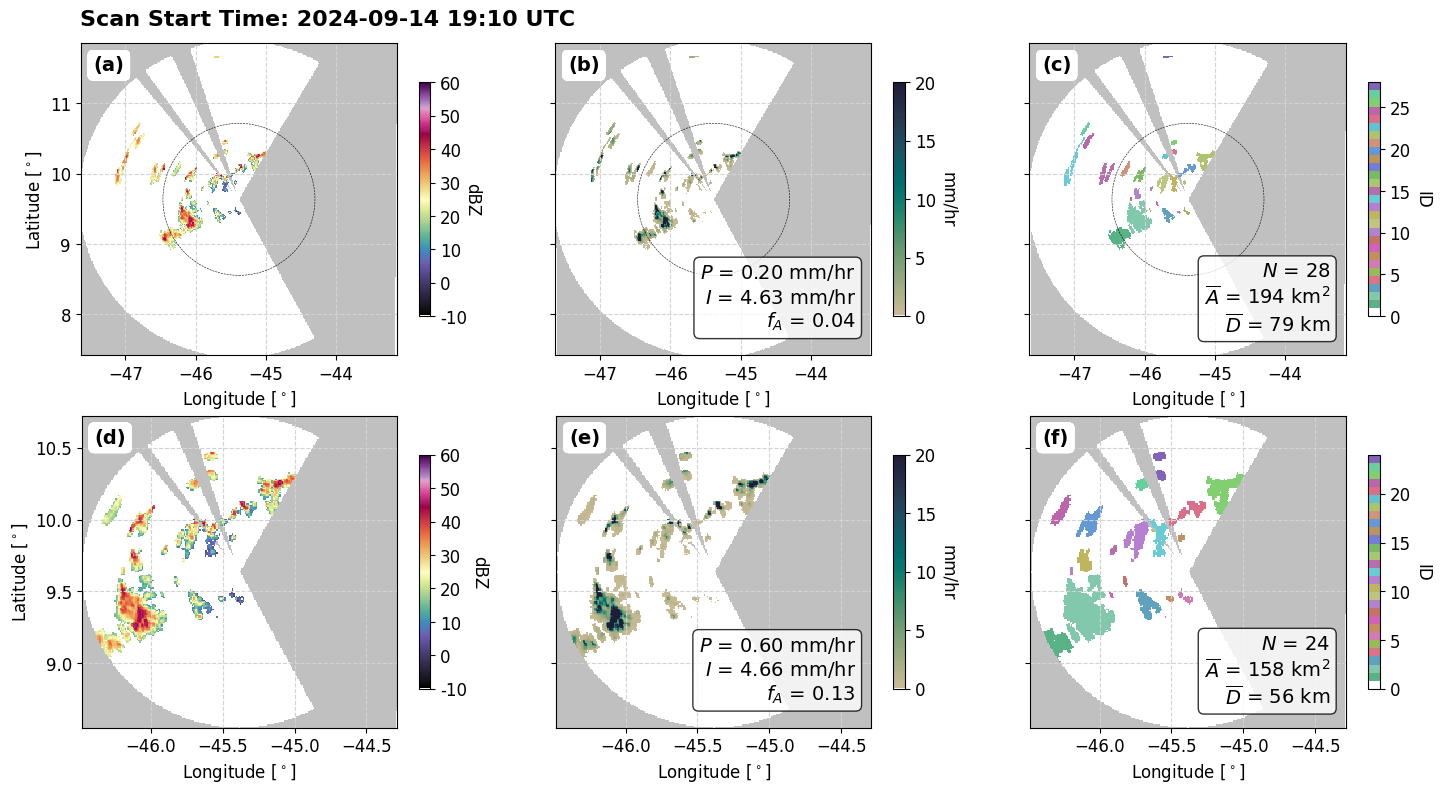

In [72]:
import matplotlib as mpl
from matplotlib.patches import Circle

# Set up cropped arrays for plotting 120 km radius data. 
start_idx = (491 - 241) // 2
end_idx = start_idx + 241
latitude_cropped = latitude[:, start_idx:end_idx, start_idx:end_idx]
longitude_cropped = longitude[:, start_idx:end_idx, start_idx:end_idx]
x_cropped = x[start_idx:end_idx]
y_cropped = y[start_idx:end_idx]
latitude_120km = latitude[:, start_idx:end_idx, start_idx:end_idx]
longitude_120km = longitude[:, start_idx:end_idx, start_idx:end_idx]
x_cropped = x[start_idx:end_idx]
y_cropped = y[start_idx:end_idx]

# Rainrate array. 
rr_array  = rr_120km[:, start_idx:end_idx, start_idx:end_idx]
orig_mask = rr_array.mask if hasattr(rr_array, 'mask') else np.isnan(rr_array)
orig_shape = rr_array.shape

# Reflectivity array.
dbz_array = dbz_120km[:, start_idx:end_idx, start_idx:end_idx]
orig_shape = dbz_array.shape

# Set desired radar scan_time. 
t = 6624 # index in short range list
t_245 = 4226 # index in long range list 

# Set up figure. 
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey='row')
axes = axes.flatten()

# Define the color maps. 
cmap_dbz = mcolors.ListedColormap(['white'] + list(plt.cm.get_cmap('ChaseSpectral')(np.linspace(0, 1, 256))))
cmap_dbz.set_bad('silver')
bounds = [-9999, -100, 60]
norm = mcolors.BoundaryNorm(bounds, cmap_dbz.N)
rain = cmocean.cm.rain
cmap_rr = mcolors.ListedColormap(['white'] + list(rain(np.linspace(0.2, 1, 256))))
cmap_rr.set_bad('silver')
bounds_rr = [-9999, 0, 0.000001, 100]
norm_rr = mcolors.BoundaryNorm(bounds_rr, cmap_rr.N)
time = scan_time[t]

# Plot 245 km, long-range reflectivity.
ax = axes[0]
c = ax.pcolormesh(longitude[t,:,:], latitude[t,:,:], dbz[t,:,:], cmap=cmap_dbz)
cbar = fig.colorbar(c, ax=ax, label='dBZ', shrink=0.75)
cbar.set_label('dBZ', rotation=270, labelpad=10, fontsize=12)
c.set_clim(-10, 60)
cbar.set_ticks(np.arange(-10, 70, 10))
cbar.set_ticklabels(np.arange(-10, 70, 10), fontsize=12)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=12)
ax.set_ylabel('Latitude [$^\\circ$]', fontsize=12)
ax.set_xticks(np.arange(np.floor(longitude[t,:,:].min()), np.ceil(longitude[t,:,:].max()) + 1, 1))
ax.set_yticks(np.arange(np.floor(latitude[t,:,:].min()), np.ceil(latitude[t,:,:].max()) + 1, 1))
ax.set_xlim(longitude[t,:,:].min(), longitude[t,:,:].max())
ax.set_ylim(latitude[t,:,:].min(), latitude[t,:,:].max())
ax.grid(True, linestyle='--', color='lightgray')
ax.tick_params(axis='both', labelsize=12)

# Draw short range circle. 
center_lon = np.mean(longitude[t, :, :])
center_lat = np.mean(latitude[t, :, :])
radius_km = 120
radius_deg = radius_km / 111.0
circle = Circle((center_lon, center_lat), radius_deg, edgecolor='black', facecolor='none', linestyle='--', linewidth=0.4, zorder=200, transform=ax.transData)
ax.add_patch(circle)

# Plot 245 km, long-range rainrate.
ax = axes[1]
c = ax.pcolormesh(longitude[t,:,:], latitude[t,:,:], rainrate[t,:,:], cmap=cmap_rr)
cbar = fig.colorbar(c, ax=ax, label='mm/hr', shrink=0.75)
cbar.set_label('mm/hr', rotation=270, labelpad=15, fontsize=12)
cbar.set_ticks(np.arange(0, 25, 5))
cbar.set_ticklabels(np.arange(0, 25, 5), fontsize=12)
c.set_clim(0, 20)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=12)
ax.set_xticks(np.arange(np.floor(longitude[t,:,:].min()), np.ceil(longitude[t,:,:].max()) + 1, 1))
ax.set_yticks(np.arange(np.floor(latitude[t,:,:].min()), np.ceil(latitude[t,:,:].max()) + 1, 1))
ax.set_xlim(longitude[t,:,:].min(), longitude[t,:,:].max())
ax.set_ylim(latitude[t,:,:].min(), latitude[t,:,:].max())
ax.grid(True, linestyle='--', color='lightgray')
ax.tick_params(axis='both', labelsize=12)

# Plot long range metrics text box.
textstr = f'$P$ = {precip_245[t_245]:.2f} mm/hr\n$I$ = {intensity_245[t_245]:.2f} mm/hr\n$f_A$ = {fa_245[t_245]:.2f}'
ax.text(
    0.95, 0.3, textstr, transform=ax.transAxes,
    fontsize=14, verticalalignment='top', zorder=201,
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Draw short range circle.
radius_km = 120
radius_deg = radius_km / 111.0
circle = Circle((center_lon, center_lat), radius_deg, edgecolor='black', facecolor='none', linestyle='--', linewidth=0.4, zorder=200, transform=ax.transData)
ax.add_patch(circle)

# Plot 245 km, long-range entity map. 
dbz_array = dbz[t, :, :]
if not np.all(np.isnan(dbz_array)):
    rain_mask_full = np.where(np.isnan(dbz[t, :, :]), 0, np.where(dbz[t, :, :] >= -30, 1, 0))
    s = generate_binary_structure(2, 2)
    cluster_mask, num_clusters = label(rain_mask_full, structure=s)
else:
    cluster_mask = np.full_like(dbz_array, np.nan)
    num_clusters = 0

def id_to_color(entity_id):
    np.random.seed(entity_id)
    hue = np.random.uniform(0, 1)
    sat = np.random.uniform(0.35, 0.55)
    val = np.random.uniform(0.7, 0.85)
    rgb = mcolors.hsv_to_rgb([hue, sat, val])
    return mcolors.to_hex(rgb)

num_clusters = int(np.nanmax(cluster_mask)) if np.isfinite(np.nanmax(cluster_mask)) else 0
color_list = ['#FFFFFF'] + [id_to_color(i) for i in range(1, num_clusters + 1)]
cluster_cmap = mcolors.ListedColormap(color_list)
vmin, vmax = 0, num_clusters
rain_rate_array = rainrate[t, :, :]
rain_rate_array_nan = np.where(rain_rate_array == '--', np.nan, rain_rate_array)
cluster_mask = np.where(rain_rate_array_nan == -32768, np.nan, cluster_mask)
cluster_cmap.set_bad('silver')
ax = axes[2]
cluster_mask_plot = np.ma.masked_where(np.isnan(dbz[t,:,:]), cluster_mask)
im = ax.pcolormesh(longitude[t,:,:], latitude[t,:,:], cluster_mask_plot,
                   cmap=cluster_cmap, vmin=vmin, vmax=vmax)
cbar = fig.colorbar(im, ax=ax, shrink=0.75)
cbar.set_label('ID', rotation=270, labelpad=15, fontsize=12)
cbar.set_ticks(np.arange(0, vmax + 1, 5))
cbar.ax.tick_params(labelsize=12)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=12)
ax.grid(True, linestyle='--', color='lightgray')
ax.tick_params(axis='both', labelsize=12)

# Plot long range entity metrics text box.
textstr2 = f'$N$ = {n_245[t_245]:.0f}\n$\\overline{{A}}$ = {abar_245[t_245]:.0f} km$^2$\n$\\overline{{D}}$ = {dbar_245[t_245]:.0f} km'
ax.text(
    0.95, 0.3, textstr2, transform=ax.transAxes,
    fontsize=14, verticalalignment='top', zorder=201,
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Draw short range circle.
circle = Circle((center_lon, center_lat), radius_deg,
                edgecolor='black', facecolor='none',
                linestyle='--', linewidth=0.4, zorder=200,
                transform=ax.transData)
ax.add_patch(circle)

# Plot 120 km, short-range reflectivity.
rr_array = rr_120km[t,start_idx:end_idx,start_idx:end_idx]
dbz_array = dbz_120km[t,start_idx:end_idx,start_idx:end_idx]
ax = axes[3]
c = ax.pcolormesh(longitude_120km[t,:,:], latitude_120km[t,:,:], dbz_array, cmap=cmap_dbz)
cbar = fig.colorbar(c, ax=ax, label='dBZ', shrink=0.75)
cbar.set_label('dBZ', rotation=270, labelpad=15, fontsize=12)
c.set_clim(-10, 60)
cbar.set_ticks(np.arange(-10, 70, 10))
cbar.set_ticklabels(np.arange(-10, 70, 10), fontsize=12)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=12)
ax.set_ylabel('Latitude [$^\\circ$]', fontsize=12)
lon_ticks = np.arange(np.floor(np.nanmin(longitude_cropped[t,:,:])), np.ceil(np.nanmax(longitude_cropped[t,:,:])) + 0.5, 0.5)
lat_ticks = np.arange(np.floor(np.nanmin(latitude_cropped[t,:,:])), np.ceil(np.nanmax(latitude_cropped[t,:,:])) + 0.5, 0.5)
ax.set_xticks(lon_ticks)
ax.set_yticks(lat_ticks)
ax.set_xlim(np.nanmin(longitude_cropped[t,:,:]), np.nanmax(longitude_cropped[t,:,:]))
ax.set_ylim(np.nanmin(latitude_cropped[t,:,:]), np.nanmax(latitude_cropped[t,:,:]))
ax.grid(True, linestyle='--', color='lightgray')
ax.tick_params(axis='both', labelsize=12)

# Plot 120 km, short-range rainrate.
ax = axes[4]
c = ax.pcolormesh(longitude_120km[t,:,:], latitude_120km[t,:,:], rr_array, cmap=cmap_rr)
cbar = fig.colorbar(c, ax=ax, label='mm/hr', shrink=0.75)
cbar.set_label('mm/hr', rotation=270, labelpad=15, fontsize=12)
cbar.set_ticks(np.arange(0, 25, 5))
cbar.set_ticklabels(np.arange(0, 25, 5), fontsize=12)
c.set_clim(0, 20)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=12)
lon_ticks = np.arange(np.floor(np.nanmin(longitude_cropped[t,:,:])), np.ceil(np.nanmax(longitude_cropped[t,:,:])) + 0.5, 0.5)
lat_ticks = np.arange(np.floor(np.nanmin(latitude_cropped[t,:,:])), np.ceil(np.nanmax(latitude_cropped[t,:,:])) + 0.5, 0.5)
ax.set_xticks(lon_ticks)
ax.set_yticks(lat_ticks)
ax.set_xlim(np.nanmin(longitude_cropped[t,:,:]), np.nanmax(longitude_cropped[t,:,:]))
ax.set_ylim(np.nanmin(latitude_cropped[t,:,:]), np.nanmax(latitude_cropped[t,:,:]))
ax.grid(True, linestyle='--', color='lightgray')
ax.tick_params(axis='both', labelsize=12)

# Plot short range metrics text box.
textstr2 = f'$P$ = {precip_all_120[t]:.2f} mm/hr\n$I$ = {intensity_all_120[t]:.2f} mm/hr\n$f_A$ = {fa_all_120[t]:.2f}'
ax.text(
    0.95, 0.3, textstr2, transform=ax.transAxes,
    fontsize=14, verticalalignment='top', zorder=201,
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 120 km, short-range entity map.
cluster_mask_zoom = cluster_mask[start_idx:end_idx, start_idx:end_idx]
rain_rate_array_zoom = rr_120km[t, start_idx:end_idx, start_idx:end_idx]
bad_mask_zoom = (
    np.ma.getmask(rain_rate_array_zoom)
    | np.isnan(rain_rate_array_zoom)
    | (rain_rate_array_zoom == '--')
    | (rain_rate_array_zoom == -32768)
)
cluster_mask_zoom = np.where(bad_mask_zoom, np.nan, cluster_mask_zoom)
ax = axes[5]
vmin = 0
vmax = 24
im = ax.pcolormesh(
    longitude_120km[t, :, :],
    latitude_120km[t, :, :],
    cluster_mask_zoom,
    cmap=cluster_cmap,
    vmin=vmin, vmax=vmax
)
norm_cbar = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
sm = mpl.cm.ScalarMappable(cmap=cluster_cmap, norm=norm_cbar)
sm.set_array([]) 
cbar = fig.colorbar(sm, ax=ax, shrink=0.75)
cbar.set_label('ID', rotation=270, labelpad=15, fontsize=12)
cbar.set_ticks(np.arange(0, vmax + 1, 5))
cbar.ax.tick_params(labelsize=12)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=12)
ax.grid(True, linestyle='--', color='lightgray')
ax.tick_params(axis='both', labelsize=12)

# Plot short range entity metrics text box.
textstr2 = f'$N$ = {n_all_120[t]:.0f}\n$\\overline{{A}}$ = {abar_all_120[t]:.0f} km$^2$\n$\\overline{{D}}$ = {dbar_all_120[t]:.0f} km'
ax.text(
    0.95, 0.3, textstr2, transform=ax.transAxes,
    fontsize=14, verticalalignment='top', zorder=201,
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Label the subplots. 
for ax in axes:
    ax.set_aspect('equal')
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
    for i, ax in enumerate(axes):
        ax.text(
            0.04, 0.96, labels[i],
            transform=ax.transAxes,
            fontsize=14,
            fontweight='bold',
            va='top',
            ha='left',
            zorder=300,
            bbox=dict(boxstyle='round', facecolor='white', alpha=1, edgecolor='none')
        )

# Add bold title showing the scan start time. 
fig.suptitle(f"Scan Start Time: {time} UTC", fontsize=16, fontweight = 'bold', y=0.98, x = 0.245)

plt.tight_layout()
plt.show()

### 📈 Figure 2 (longrange_metrics_timeseries.png)

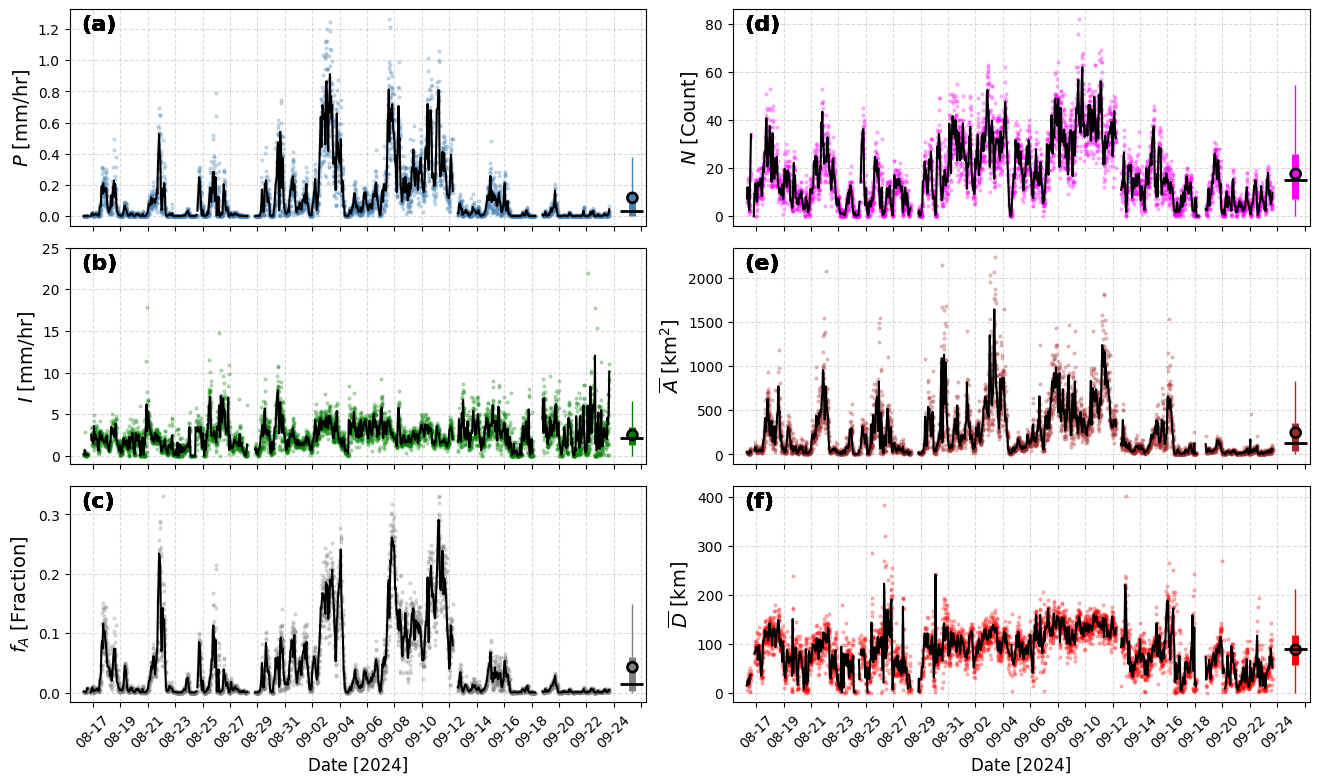

In [73]:
from matplotlib import transforms
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D

# Set up a 3x2 grid of subplots for time series, with shared x-axis in each column and custom spacing.
fig, axs = plt.subplots(3, 2, figsize=(16, 9),
                       gridspec_kw={'height_ratios': [1, 1, 1], 'wspace': 0.15, 'hspace': 0.10},
                       sharex='col')

# Define a helper function to compute the 25th percentile (Q1), median (Q2), 75th percentile (Q3), and mean of a list of values, ignoring NaNs.
def _q_stats(data):
    vals = np.array([v for v in data if not np.isnan(v)])
    if vals.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    q1, q2, q3 = np.nanpercentile(vals, [25, 50, 75])
    mean = np.nanmean(vals)
    return q1, q2, q3, mean

# Map each metric to its corresponding subplot axes.
ax_precip = axs[0, 0]
ax_intensity = axs[1, 0]
ax_fa = axs[2, 0]
ax_n = axs[0, 1]
ax_abar = axs[1, 1]
ax_dbar = axs[2, 1]

# Set the start and end date for the time series plot. 
start_num = mdates.date2num(mdates.datetime.datetime(2024, 8, 15, 12))
end_num = mdates.date2num(mdates.datetime.datetime(2024, 9, 24))
span = end_num - start_num
pad_left = -0.005 * span    # tiny left pad (0.5% of span)
pad_right = 0.06 * span     # 5% right pad to ensure glyphs at axes-fraction ~0.98 are visible

# Time-series plots in the left column. 
# Precipitation P. 
ax_precip.plot(standard_time_grid, precip_all_245_fill, 'o', markersize=2, alpha=0.25, color='steelblue')
ax_precip.plot(precip_weighted_index_list, precip_weighted, '-', color='black', linewidth=1.5)
ax_precip.grid(True, linestyle='--', alpha=0.45)
ax_precip.set_ylabel('$P$ [mm/hr]', fontsize=14)

#Intensity I.
ax_intensity.plot(standard_time_grid, intensity_all_245_fill, 'o', markersize=2, alpha=0.25, color='green')
ax_intensity.plot(precip_weighted_index_list, intensity_weighted, '-', color='black', linewidth=1.5)
ax_intensity.set_ylim(-1, 25) # Cap the y-axis for better visualization. 
ax_intensity.set_ylabel('$I$ [mm/hr]', fontsize=14)
ax_intensity.grid(True, linestyle='--', alpha=0.45)

# Fractional area fA.
ax_fa.plot(standard_time_grid, fa_all_245_fill, 'o', markersize=2, alpha=0.25, color='gray')
ax_fa.plot(precip_weighted_index_list, fa_weighted, '-', color='black', linewidth=1.5)
ax_fa.set_ylabel('$f_A$ [Fraction]', fontsize=14)
ax_fa.grid(True, linestyle='--', alpha=0.45)
ax_fa.set_xlabel('Date [2024]', fontsize=12)

# Time-series plots in the right column. 
# Number N. 
ax_n.plot(standard_time_grid, n_all_245_fill, 'o', markersize=2, alpha=0.25, color='magenta')
ax_n.plot(precip_weighted_index_list, n_weighted, '-', color='black', linewidth=1.5)
ax_n.set_ylabel('$N$ [Count]', fontsize=14)
ax_n.grid(True, linestyle='--', alpha=0.45)

# Average area Abar. 
ax_abar.plot(standard_time_grid, abar_all_245_fill, 'o', markersize=2, alpha=0.25, color='brown')
ax_abar.plot(precip_weighted_index_list, abar_weighted, '-', color='black', linewidth=1.5)
ax_abar.set_ylabel('$\\overline{A}$ [km$^2$]', fontsize=14)
ax_abar.grid(True, linestyle='--', alpha=0.45)

# Average edge-to-edge distance Dbar.
ax_dbar.plot(standard_time_grid, dbar_all_245_fill, 'o', markersize=2, alpha=0.25, color='red')
ax_dbar.plot(precip_weighted_index_list, dbar_weighted, '-', color='black', linewidth=1.5)
ax_dbar.set_ylabel('$\\overline{D}$ [km]', fontsize=14)
ax_dbar.grid(True, linestyle='--', alpha=0.45)
ax_dbar.set_xlabel('Date [2024]', fontsize=12)

# Set the xlim for each plot. 
for ax in [ax_precip, ax_intensity, ax_fa, ax_n, ax_abar, ax_dbar]:
    ax.set_xlim([start_num + pad_left, end_num + pad_right])

# Compute and draw boxplots on the far right of each time series plot. 
plot_items = [
    (ax_precip, precip_245, 'steelblue'),
    (ax_intensity, intensity_245, 'green'),
    (ax_fa, fa_245, 'gray'),
    (ax_n, n_245, 'magenta'),
    (ax_abar, abar_245, 'brown'),
    (ax_dbar, dbar_245, 'red'),
]
for ax, data_list, dot_color in plot_items:
    q1, q2, q3, mean_val = _q_stats(data_list)
    if np.isnan(q1):
        continue

    xpos_frac = 0.975       # move a bit closer to the right edge
    dx_frac = 0.02        # horizontal half-width

    trans = transforms.blended_transform_factory(ax.transAxes, ax.transData)

    # Bold the IQR vertical line to make it more visible.
    iqr_line = Line2D([xpos_frac, xpos_frac], [q1, q3],
                      transform=trans, color=dot_color,
                      linewidth=5, solid_capstyle='butt', zorder=4)
    ax.add_line(iqr_line)

    # Add a black line for the median. 
    med_line = Line2D([xpos_frac - dx_frac, xpos_frac + dx_frac], [q2, q2],
                      transform=trans, color='black',
                      linewidth=2, solid_capstyle='butt', zorder=5)
    ax.add_line(med_line)

    # Add a black circle for the mean. 
    ax.scatter([xpos_frac + dx_frac * .045], [mean_val], transform=trans,
               edgecolor='black', facecolor='none', s=50,
               linewidths=2, zorder=6)

    # Add skinny whisker lines that extend to the last point within 1.5*IQR of the quartiles.
    # Define the lines.
    iqr = q3 - q1
    data_vals = np.array([v for v in data_list if not np.isnan(v)])
    if data_vals.size == 0:
        continue
    whisker_low = max(q1 - 1.5 * iqr, data_vals.min())
    whisker_high = min(q3 + 1.5 * iqr, data_vals.max())

    # Plot the lines. 
    whisk_low_line = Line2D([xpos_frac, xpos_frac], [q1, whisker_low],
                            transform=trans, color=dot_color,
                            linewidth=1, solid_capstyle='butt', zorder=3)
    whisk_high_line = Line2D([xpos_frac, xpos_frac], [q3, whisker_high],
                             transform=trans, color=dot_color,
                             linewidth=1, solid_capstyle='butt', zorder=3)
    ax.add_line(whisk_low_line)
    ax.add_line(whisk_high_line)


# Set x-limits, format x-axis and show (keep the added right padding). 
for ax in [ax_precip, ax_intensity, ax_fa, ax_n, ax_abar, ax_dbar]:
    ax.set_xlim([start_num + pad_left, end_num + pad_right])
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', labelsize=10, rotation=45)
    ax.figure.canvas.draw_idle()
    
    # Add vertical labels. 
    axes = [ax_precip, ax_intensity, ax_fa, ax_n, ax_abar, ax_dbar]
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
    for i, ax in enumerate(axes):
        ax.text(
            0.02, 0.975, labels[i],
            transform=ax.transAxes,
            fontsize=16,
            fontweight='bold',
            va='top',
            ha='left',
            rotation='horizontal',
            zorder=300
        )

# Hide any x-tick that formats to '09-26' to avoid overlap with the rightmost boxplot.
for ax in [ax_precip, ax_intensity, ax_fa, ax_n, ax_abar, ax_dbar]:
    for lbl in ax.xaxis.get_ticklabels():
        if '09-26' in lbl.get_text().strip():
            lbl.set_visible(False)

plt.show()

### 🔗 Figure 3 (shortrange_correlations.png)

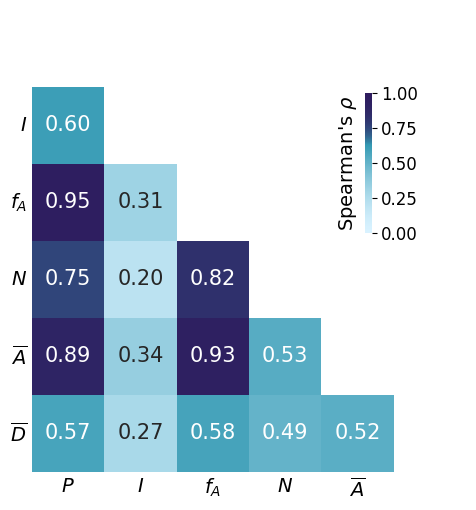

In [75]:
from matplotlib.colors import ListedColormap

# Create a custom color map for plotting the correlation matrix with a teal to purple gradient. 
pale_teal = np.array([0.85, 0.95, 1.0])   # lighter blue (more blue than green)
mid_teal  = np.array([0.2, 0.6, 0.7])     # keep mid teal, slightly bluer
dark_teal = np.array([0.18, 0.08, 0.35])  # dark purple shade

# Number of color stops for the linear and exponential sections of the colormap.
n_linear = 250
n_exp = 150
linear_x = np.linspace(0, 1, n_linear)**1.5
colors_linear = pale_teal + (mid_teal - pale_teal) * linear_x[:, None]
exp_x = np.linspace(0, 1, n_exp)
factor = 1 - (1 - np.exp(-3*exp_x))
colors_exp = mid_teal * factor[:, None] + dark_teal * (1 - factor[:, None])
colors = np.vstack([colors_linear, colors_exp])
custom_cmap = ListedColormap(colors) # name the color map 


# Create a data fram of metrics to compute the correlations between. 
metrics_df = pd.DataFrame({
    'precip': precip_all_120,
    'intensity': intensity_all_120,
    'fa': fa_all_120,
    'n': n_all_120,
    'abar': abar_all_120,
    'dbar': dbar_all_120
})

# Create a blank matrix to store the results, 
cols = metrics_df.columns
n = len(cols)
corr2 = np.zeros((n, n))
pval2 = np.ones((n, n))

# For each pair of metrics, compute the Spearman correlation while accounting for autocorrelation, and store the results in the matrices.
for i in range(n):
    for j in range(n):
        x = metrics_df.iloc[:, i].values
        y = metrics_df.iloc[:, j].values
        mask = ~(np.isnan(x) | np.isnan(y))
        if np.sum(mask) > 2:
            rho, p, _ = spearman_with_autocorr(x[mask], y[mask])
            corr2[i, j] = rho
            pval2[i, j] = p
        else:
            corr2[i, j] = np.nan
            pval2[i, j] = np.nan

# Create a mask to only show the lower triangle of the correlation matrix (since it's symmetric) and to hide the diagonal.
mask2 = np.zeros_like(corr2, dtype=bool)
np.fill_diagonal(mask2, True)
for i in range(n):
    for j in range(i+1, n):
        mask2[i, j] = True

# Find the correlations that are significant at the 99% confidence level. 
sig_mask2 = np.full(corr2.shape, '', dtype=object)
for i in range(n):
    for j in range(n):
        if i > j and pval2[i, j] < 0.01:
            sig_mask2[i, j] = '*'

# Set up the figure.
div_point = np.sqrt(0.5)
non_sig_mask = (sig_mask2 != '*')
corr2_plot = corr2.copy()
corr2_plot[non_sig_mask] = np.nan
yticklabels = ['', '$I$', '$f_A$', '$N$', '$\\overline{A}$', '$\\overline{D}$'] 
xticklabels = ['$P$', '$I$', '$f_A$', '$N$', '$\\overline{A}$', '']
plt.figure(figsize=(7, 6))

# Plot the correlation matrix with the custom teal-purple colormap, while masking the upper right triangle. 
ax = sns.heatmap(
    np.abs(corr2_plot), annot=corr2_plot, fmt='.2f', cmap=custom_cmap, vmin = 0, vmax = 1, mask=mask2,
    yticklabels=yticklabels,
    xticklabels=xticklabels,
    cbar_kws={'ticks': np.linspace(0,1,5)}, 
    annot_kws = {'fontsize':15},
)

# Customize the colorbar and axes ticks.
ax.collections[0].colorbar.set_ticklabels([f"{v:.2f}" for v in np.linspace(0,1,5)], fontsize=12)
ax.collections[0].colorbar.set_label("Spearman's $\\rho$", fontsize=14)
cbar = plt.gca().collections[0].colorbar
cbar.ax.set_position([0.6, 0.45, 0.01, 0.35])
cbar.ax.yaxis.set_label_position('left')

# Format the x and y ticks. 
plt.gca().tick_params(axis='x', length=0, labelsize=14)
plt.gca().tick_params(axis='y', length=0, rotation=0, labelsize=14)

# Show the figure. 
plt.show()

### 🗄️ Figure 4 (shortrange_hexbins.png)

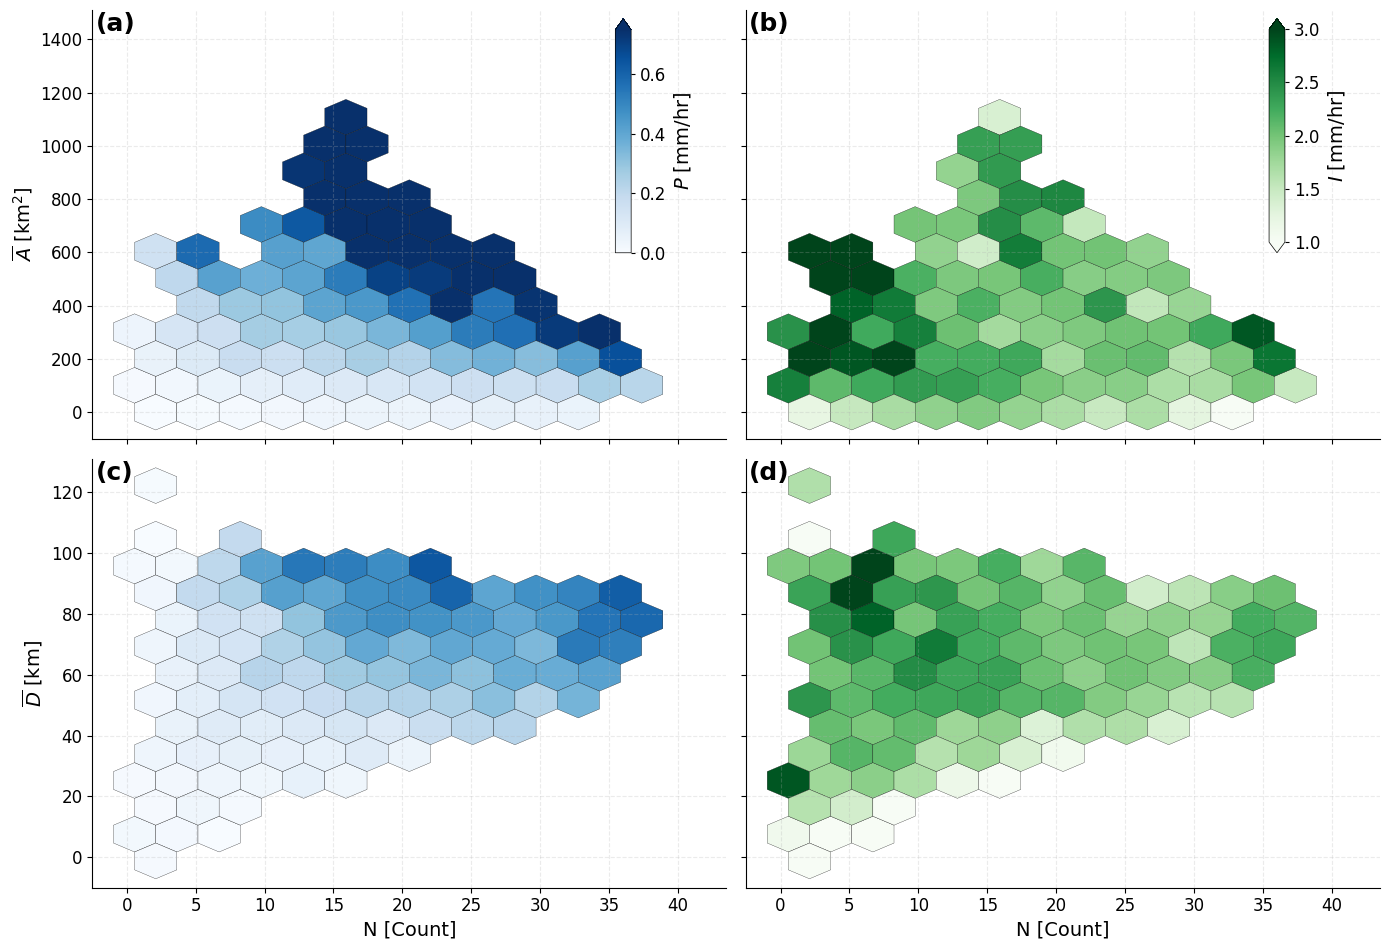

In [77]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create arrays for the 120 km metrics for easier plotting. 
n_arr = np.array(n_all_120, dtype=float)
abar_arr = np.array(abar_all_120, dtype=float)
dbar_arr = np.array(dbar_all_120, dtype=float)
fa_arr = np.array(fa_all_120, dtype=float)
precip_arr = np.array(precip_all_120, dtype=float)
intensity_arr = np.array(intensity_all_120, dtype=float)

# Prepare masks to filter out any NaNs. 
mask_abar = (
    np.isfinite(n_arr) &
    np.isfinite(abar_arr) &
    np.isfinite(intensity_arr) &
    np.isfinite(fa_arr) &
    np.isfinite(precip_arr)
)
mask_dbar = (
    np.isfinite(n_arr) &
    np.isfinite(dbar_arr) &
    np.isfinite(intensity_arr) &
    np.isfinite(fa_arr) &
    np.isfinite(precip_arr)
)
n_abar = n_arr[mask_abar]
abar_v = abar_arr[mask_abar]
int_abar = intensity_arr[mask_abar]
precip_abar = precip_arr[mask_abar]
n_dbar = n_arr[mask_dbar]
dbar_v = dbar_arr[mask_dbar]
int_dbar = intensity_arr[mask_dbar]
precip_dbar = precip_arr[mask_dbar]

# Set common x and y limits, ticks, and color limits for the hexbin plots.
xlim = (-2.5, 43.5)
xticks = np.arange(0, 41, 5)
ylim_abar = (-100, 1510)   # top row y limits
ylim_dbar = (-10, 131)   # bottom row y limits

# Set color limits for the precipitation and intensity shading. 
precip_vmin, precip_vmax = (0, 0.75)
int_vmin, int_vmax = (1, 3)

# Create a 2x2 grid of subplots. 
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex='col')

# Set the grid size, minimum count for each hexbin, and the edge ling width. 
gridsize = 15
mincnt = 10
edge_lw = 0.2

# Plot (a): Abar verus N, shaded by P.
ax = axes[0, 0]
hb00 = ax.hexbin(
    n_abar, abar_v, C=precip_abar,
    gridsize=gridsize, cmap='Blues', mincnt=mincnt,
    reduce_C_function=np.nanmean,
    extent=(xlim[0], xlim[1], ylim_abar[0], ylim_abar[1]),
    edgecolors='black', linewidths=edge_lw
)
hb00.set_clim(precip_vmin, precip_vmax)

# Plot (b): Abar verus N, shaded by I.
ax = axes[0, 1]
hb01 = ax.hexbin(
    n_abar, abar_v, C=int_abar,
    gridsize=gridsize, cmap='Greens', mincnt=mincnt,
    reduce_C_function=np.nanmean,
    extent=(xlim[0], xlim[1], ylim_abar[0], ylim_abar[1]),
    edgecolors='black', linewidths=edge_lw
)
hb01.set_clim(int_vmin, int_vmax)

# Plot (c): Dbar verus N, shaded by P.
ax = axes[1, 0]
hb10 = ax.hexbin(
    n_dbar, dbar_v, C=precip_dbar,
    gridsize=gridsize, cmap='Blues', mincnt=mincnt,
    reduce_C_function=np.nanmean,
    extent=(xlim[0], xlim[1], ylim_dbar[0], ylim_dbar[1]),
    edgecolors='black', linewidths=edge_lw
)
hb10.set_clim(precip_vmin, precip_vmax)

# Plot (d): Dbar verus N, shaded by I.
ax = axes[1, 1]
hb11 = ax.hexbin(
    n_dbar, dbar_v, C=int_dbar,
    gridsize=gridsize, cmap='Greens', mincnt=mincnt,
    reduce_C_function=np.nanmean,
    extent=(xlim[0], xlim[1], ylim_dbar[0], ylim_dbar[1]),
    edgecolors='black', linewidths=edge_lw
)
hb11.set_clim(int_vmin, int_vmax)

# Only add colorbars for the top row (left = P, right = I), as slim bars. 
cax0 = inset_axes(axes[0, 0], width="10%", height="70%", loc='upper right',
                  bbox_to_anchor=(0.6, 0.2, 0.25, 0.78), bbox_transform=axes[0, 0].transAxes, borderpad=0)
cb0 = fig.colorbar(hb00, cax=cax0, orientation='vertical', extend='max')
cb0.set_label('$P$ [mm/hr]', fontsize=14)
cb0.ax.tick_params(labelsize=12, length=3)
for spine in cax0.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)
cax1 = inset_axes(axes[0, 1], width="10%", height="70%", loc='upper right',
                  bbox_to_anchor=(0.6, 0.2, 0.25, 0.78), bbox_transform=axes[0, 1].transAxes, borderpad=0)
cb1 = fig.colorbar(hb01, cax=cax1, orientation='vertical', extend='both')
cb1.set_label('$I$ [mm/hr]', fontsize=14)
cb1.ax.tick_params(labelsize=12, length=3)
for spine in cax1.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.5)

# Labels, limits, ticks and styling. 
for row in range(2):
    for col in range(2):
        ax = axes[row, col]
        ax.set_xlim(xlim)
        ax.set_xticks(xticks)
        ax.grid(True, linestyle='--', alpha=0.25)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

# Y labels for left column only.
axes[0, 0].set_ylabel('$\\overline{A}$ [km$^2$]', fontsize=14)
axes[1, 0].set_ylabel('$\\overline{D}$ [km]', fontsize=14)

# X labels for bottom row only. 
axes[1, 0].set_xlabel('N [Count]', fontsize=14)
axes[1, 1].set_xlabel('N [Count]', fontsize=14)

# Set tick label fontsize for all axes. 
for ax in axes.flat:
    ax.tick_params(axis='both', which='both', labelsize=12)

# Ensure colorbar tick labels are also size 12 if present
cb0.ax.tick_params(labelsize=12)
cb1.ax.tick_params(labelsize=12)

# Hide y tick labels for right column. 
for row in range(2):
    axes[row, 1].tick_params(axis='y', labelleft=False)

# Set y-limits per row. 
axes[0, 0].set_ylim(ylim_abar); axes[0, 1].set_ylim(ylim_abar)
axes[1, 0].set_ylim(ylim_dbar); axes[1, 1].set_ylim(ylim_dbar)

# Add subplot labels. 
for ax, label in zip(axes.flat, ['(a)', '(b)', '(c)', '(d)']):
    ax.text(0.005, 0.995, label, transform=ax.transAxes,
            fontsize=18, fontweight='bold', va='top', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 🕒 Figure 5 (lorg_rome_timeseries.png)

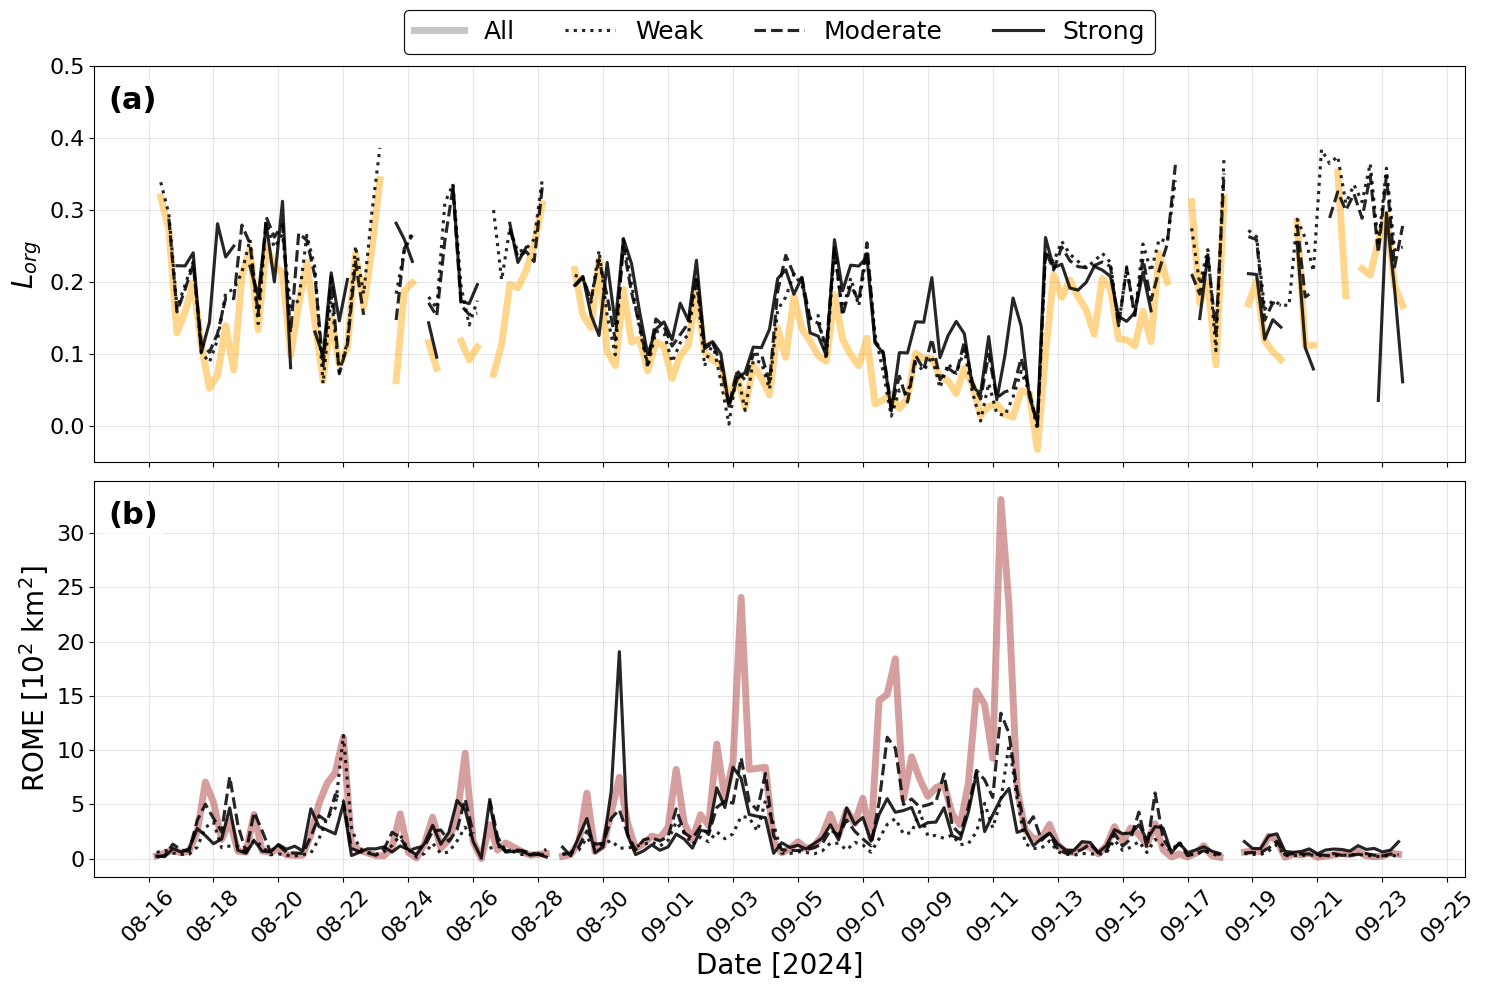

In [78]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

# Set up a 2 figure subplot. 
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Top plot: Lorg time series of all, light, moderate, and strong echoes.
axs[0].plot(standard_time_grid[hour_start_indices][::6], lorg_all_6hr, '-', color='orange', linewidth=5, alpha=0.45)
axs[0].plot(standard_time_grid[hour_start_indices][::6], lorg_light_6hr, linestyle = 'dotted', color='black', linewidth=2.25, alpha=0.85)
axs[0].plot(standard_time_grid[hour_start_indices][::6], lorg_mod_6hr, '--', color='black', linewidth=2.25, alpha=0.85)
axs[0].plot(standard_time_grid[hour_start_indices][::6], lorg_strong_6hr, '-', color='black', linewidth=2.25, alpha=0.85)
axs[0].set_ylabel('$L_{org}$', fontsize=20)
axs[0].grid(True, linestyle='-', alpha=0.3)
axs[0].tick_params(axis='y', labelsize=16)
axs[0].set_ylim([-0.05, 0.5])

# Bottom plot: ROME time series of all, light, moderate, and strong echoes.
# Divide each ROME time series by 100 to convert from km^2 to 10^2 km^2. 
# Multiply the light, moderate, and heavy ROME by 5 to make them more visible on the same plot.
axs[1].plot(rome_all_6hr.index.to_numpy(), rome_all_6hr.values / 100,
            '-', color='brown', linewidth=5, alpha=0.45)
axs[1].plot(rome_light_6hr.index.to_numpy(), (rome_light_6hr * 5).values / 100,
            linestyle='dotted', color='black', linewidth=2.25, alpha=0.85)
axs[1].plot(rome_mod_6hr.index.to_numpy(), (rome_mod_6hr * 5).values / 100,
            '--', color='black', linewidth=2.25, alpha=0.85)
axs[1].plot(rome_strong_6hr.index.to_numpy(), (rome_strong_6hr * 5).values / 100,
            '-', color='black', linewidth=2.25, alpha=0.85)

# Add labels, grid, and ticks.
axs[1].set_xlabel('Date [2024]', fontsize=20)
axs[1].set_ylabel('ROME [10$^2$ km$^2$]', fontsize=20)
axs[1].grid(True, linestyle='-', alpha=0.3)
axs[1].tick_params(axis='x', labelsize=16)
axs[1].tick_params(axis='y', labelsize=16)
for ax in axs:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    ax.tick_params(axis='x', rotation=45)

# Custom legend handles matching the plotted line styles. 
handles = [
    Line2D([0], [0], color='gray', lw=5, alpha=0.45),
    Line2D([0], [0], color='black', lw=2.25, linestyle=':', alpha=0.85),
    Line2D([0], [0], color='black', lw=2.25, linestyle='--', alpha=0.85),
    Line2D([0], [0], color='black', lw=2.25, linestyle='-', alpha=0.85),
]
labels = ['All', 'Weak', 'Moderate', 'Strong']

# Place legend above the top subplot, with a boxed frame. 
leg = axs[0].legend(handles, labels,
                    loc='lower center',
                    bbox_to_anchor=(0.5, 1),
                    ncol=4,
                    frameon=True,
                    fontsize=18)
frame = leg.get_frame()
frame.set_facecolor('white')
frame.set_edgecolor('black')
frame.set_linewidth(0.85)
frame.set_alpha(0.95)

# Label the subplots. 
axs[0].text(0.01, 0.95, '(a)', transform=axs[0].transAxes, fontsize=22, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
axs[1].text(0.01, 0.95, '(b)', transform=axs[1].transAxes, fontsize=22, fontweight='bold', va='top', ha='left', bbox=dict(facecolor='white', edgecolor='none', alpha=0.8))
plt.tight_layout()
plt.show()

### 🔖 Figure 6 (lorg_labels.png)

In [79]:
# Redefine the bins used to compute Lorg. 
bins = np.arange(0, 242, 2)
rmax = 240

# Define a function to compute the indices corresponding to the two-sided confidence 
# interval for a given list of Lorg values, based on the specified alpha level.
# Determine if the observed Lorg is significantly different from random.
def get_two_sided_index(iorg_list, alpha=0.05):

    # Find the indices corresponding to the lower and upper bounds of the confidence interval.
    lower_idx = int(np.floor((alpha / 2) * len(iorg_list)))
    upper_idx = int(np.ceil((1 - alpha / 2) * len(iorg_list))) - 1

    # Sort the list of Lorg values and retrieve the Lorg values at the lower and upper confidence indices.
    sorted_indices = np.argsort(iorg_list)
    lower_conf_idx = sorted_indices[lower_idx]
    upper_conf_idx = sorted_indices[upper_idx]

    # Return the Lorg values at the lower and upper confidence indices, as well as the indices themselves.
    low_iorg = iorg_list[lower_conf_idx]
    upper_iorg = iorg_list[upper_conf_idx]
    
    return low_iorg, upper_iorg, lower_conf_idx, upper_conf_idx

In [80]:
# Label each of the radar scenes based on Lorg values. 

# Iterate through each category (all, light, moderate, strong).
label_results = {}
for cat, obs_list, iter_list, lorg_list in zip(
    ['all', 'light', 'moderate', 'strong'],
    [obs_all, obs_light, obs_mod, obs_strong],
    [iter_all, iter_light, iter_mod, iter_strong],
    [lorg_all, lorg_light, lorg_mod, lorg_strong]
):
    labels = []
    for obs, theor_list, lorg in zip(obs_list, iter_list, lorg_list):
        
        # Skip if Lorg is NaN. 
        if np.isnan(lorg):
            labels.append(np.nan)
            continue

        # Compute the Lorg value for each random scene. 
        lorg_random = []
        for besag_theor in theor_list:
            besag_theor = besag_theor / rmax
            lorg_rand = np.trapezoid(obs - besag_theor, x=bins) / rmax
            lorg_random.append(lorg_rand)

        # Find the two-sided confidence interval for the random Lorg values and label the observed Lorg accordingly.
        low, high, _, _ = get_two_sided_index(lorg_random, alpha=0.05)
        if low < 0 and high < 0: # both bounds are negative, so observed Lorg is significantly more negative than random (regular)
            label = 'regular'
        elif low <= 0 and high >= 0: # confidence interval includes 0, so observed Lorg is not significantly different from random
            label = 'random'
        elif low > 0 and high > 0: # both bounds are positive, so observed Lorg is significantly more positive than random (organized)
            label = 'organized'
        labels.append(label)

    # Save the results. 
    label_results[cat] = labels

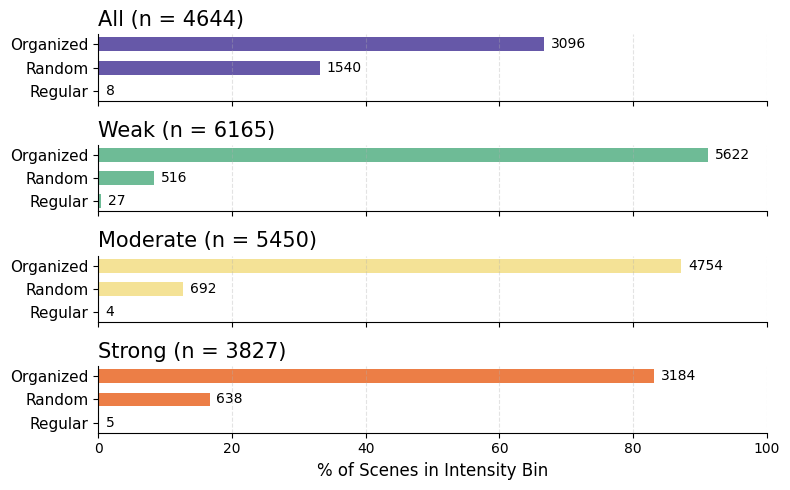

In [81]:
# Create a plot with stacked horizontal bar charts (4 blocks, each with 3 horizontal bars), shared x-axis.
thresholds = ['all', 'light', 'moderate', 'strong']
label_types = ['regular', 'random', 'organized']

# Compute the counts of each label type for each threshold, and the total count per threshold for percentage calculations.
counts = {thr: {lbl: int(np.sum(np.array(label_results[thr]) == lbl)) for lbl in label_types} for thr in thresholds}
total_per_thr = [sum(counts[thr].values()) for thr in thresholds]

# Display labels for plotting. 
display_labels = ['All', 'Weak', 'Moderate', 'Strong']

# Set up figure. 
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(8, 5), sharex=True)

# Define color map. 
color_map = {'all': '#6658a8', 'light': '#6ebb96', 'moderate': '#f4e296', 'strong': '#ec7e46'}
y = np.arange(len(label_types))

# Compute global max percent for consistent x-limits. 
all_pct = []
for i, thr in enumerate(thresholds):
    t = total_per_thr[i]
    pct = [100 * counts[thr][lbl] / t if t > 0 else 0 for lbl in label_types]
    all_pct.extend(pct)
xmax = min(100, max(all_pct) * 1.15 if all_pct else 100)

# Plot each row with the corresponding color, annotate counts, and style the axes.
for i, (ax, thr) in enumerate(zip(axes, thresholds)):

    t = total_per_thr[i]
    vals = [100 * counts[thr][lbl] / t if t > 0 else 0 for lbl in label_types]

    # Use threshold-specific color for this row. 
    color = color_map.get(thr, 'gray')
    bars = ax.barh(y, vals, color=color, height=0.6)

    # Annotate absolute counts at end of each bar. 
    for bar, lbl in zip(bars, label_types):
        width = bar.get_width()
        cnt = counts[thr][lbl]
        ax.text(width + xmax * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{cnt}", va='center', fontsize=10)

    # Styling. 
    ax.set_yticks(y)
    ax.set_yticklabels([lbl.capitalize() for lbl in label_types], fontsize=11)
    ax.set_xlim(0, xmax)
    ax.set_title(f"{display_labels[i]} (n = {t})", fontsize=15, loc='left')
    ax.grid(axis='x', linestyle='--', alpha=0.35)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared x label. 
axes[-1].set_xlabel('% of Scenes in Intensity Bin', fontsize=12)

plt.tight_layout()
plt.show()

### 🌐 Figure 7 (entitymap_examples.png)

In [82]:
# Spatially subset radar data to within a specified radius from SEA-POL for specified time indicies. 

t = 5904

# Extract the t-th 2D slices (as numpy arrays)
rr_t = rr[t].values if hasattr(rr[t], "values") else np.array(rr[t])
dbz_t = dbz[t].values if hasattr(dbz[t], "values") else np.array(dbz[t])

# Apply the radius mask to the t-th slice
rr_120km[t] = np.where(radius_mask, rr_t, np.nan)
dbz_120km[t] = np.where(radius_mask, dbz_t, np.nan)

# Preserve original invalid markers (NaNs and -32768) within that t-th slice
rr_invalid_t = np.isnan(rr_t) | (rr_t == -32768)
dbz_invalid_t = np.isnan(dbz_t) | (dbz_t == -32768)
rr_120km[t][rr_invalid_t] = np.nan
dbz_120km[t][dbz_invalid_t] = np.nan

print("Done masking rainrate and reflectivity for t =", t)

t = 4691

# Extract the t-th 2D slices (as numpy arrays)
rr_t = rr[t].values if hasattr(rr[t], "values") else np.array(rr[t])
dbz_t = dbz[t].values if hasattr(dbz[t], "values") else np.array(dbz[t])

# Apply the radius mask to the t-th slice
rr_120km[t] = np.where(radius_mask, rr_t, np.nan)
dbz_120km[t] = np.where(radius_mask, dbz_t, np.nan)

# Preserve original invalid markers (NaNs and -32768) within that t-th slice
rr_invalid_t = np.isnan(rr_t) | (rr_t == -32768)
dbz_invalid_t = np.isnan(dbz_t) | (dbz_t == -32768)
rr_120km[t][rr_invalid_t] = np.nan
dbz_120km[t][dbz_invalid_t] = np.nan

print("Done masking rainrate and reflectivity for t =", t)

t = 836

# Extract the t-th 2D slices (as numpy arrays)
rr_t = rr[t].values if hasattr(rr[t], "values") else np.array(rr[t])
dbz_t = dbz[t].values if hasattr(dbz[t], "values") else np.array(dbz[t])

# Apply the radius mask to the t-th slice
rr_120km[t] = np.where(radius_mask, rr_t, np.nan)
dbz_120km[t] = np.where(radius_mask, dbz_t, np.nan)

# Preserve original invalid markers (NaNs and -32768) within that t-th slice
rr_invalid_t = np.isnan(rr_t) | (rr_t == -32768)
dbz_invalid_t = np.isnan(dbz_t) | (dbz_t == -32768)
rr_120km[t][rr_invalid_t] = np.nan
dbz_120km[t][dbz_invalid_t] = np.nan

print("Done masking rainrate and reflectivity for t =", t)

Done masking rainrate and reflectivity for t = 5904
Done masking rainrate and reflectivity for t = 4691
Done masking rainrate and reflectivity for t = 836


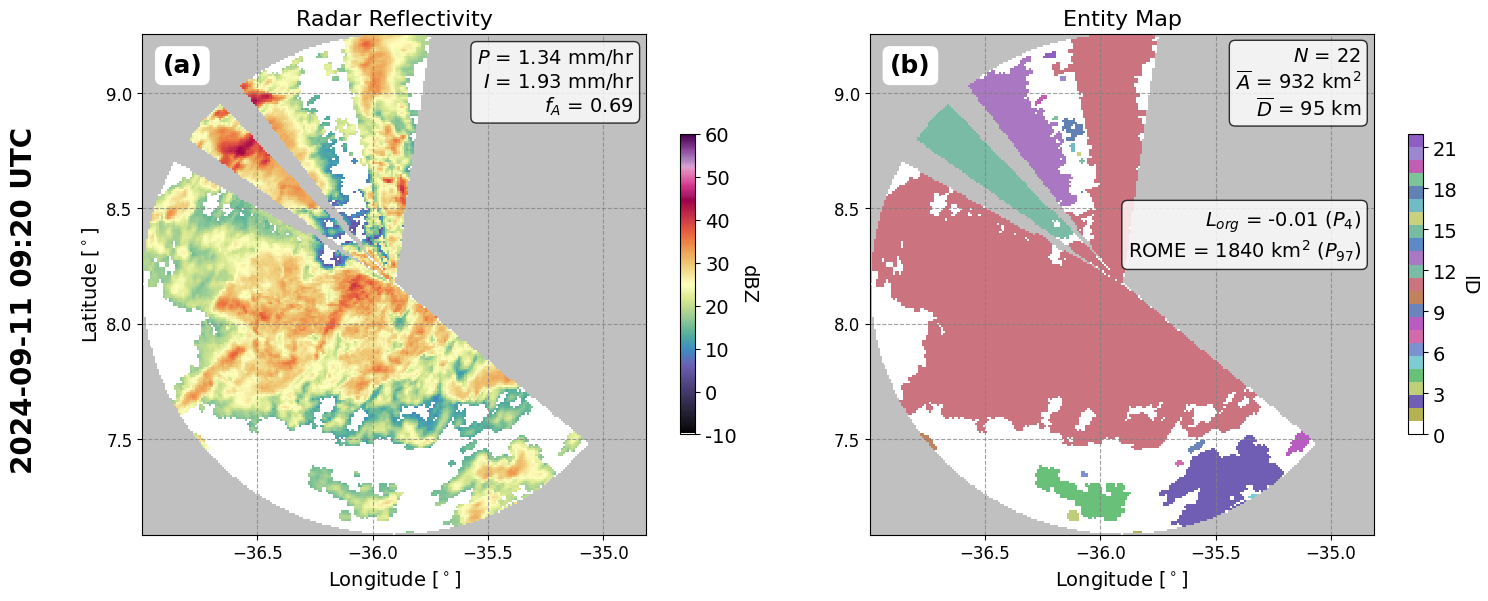

In [83]:
# Plots a and b (t = 5904 at 2024-09-11 09:20 UTC). 

from matplotlib.ticker import MaxNLocator
from scipy.ndimage import gaussian_filter, label, generate_binary_structure 

# Set time and define color maps. 
t = 5904
cmap_dbz = mcolors.ListedColormap(['white'] + list(plt.cm.get_cmap('ChaseSpectral')(np.linspace(0, 1, 256))))
cmap_dbz.set_bad('silver')
bounds = [-9999, -100, 60]
norm = mcolors.BoundaryNorm(bounds, cmap_dbz.N)
rain = cmocean.cm.rain
cmap_rr = mcolors.ListedColormap(['white'] + list(rain(np.linspace(0.2, 1, 256))))
cmap_rr.set_bad('silver')
bounds_rr = [-9999, 0, 0.000001, 1000]
norm_rr = mcolors.BoundaryNorm(bounds_rr, cmap_rr.N)
time = scan_time[t]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Plot radar reflectivity map. 
ax = axes[0]
c = ax.pcolormesh(longitude_cropped[t,:,:], latitude_cropped[t,:,:], dbz_120km[t,start_idx:end_idx,start_idx:end_idx], cmap=cmap_dbz)
cbar = fig.colorbar(c, ax=ax, label='dBZ', shrink=0.6)
cbar.set_label('dBZ', rotation=270, labelpad=15, fontsize=14)
c.set_clim(-10, 60)
cbar.set_ticks(np.arange(-10, 70, 10))
cbar.set_ticklabels(np.arange(-10, 70, 10))
cbar.ax.tick_params(labelsize=14)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=14)
ax.set_ylabel('Latitude [$^\\circ$]', fontsize=14)
ax.grid(True, linestyle='--', color='gray', alpha=0.75)
ax.set_title('Radar Reflectivity', fontsize=16)
fig.text(
    -0.01, 0.475, f'{scan_time[t]} UTC',
    va='center', ha='left',
    fontsize=20, fontweight='bold',
    rotation='vertical'
)

# Annotate with precipitation metrics. 
precip_val = precip_all_120[t]
intensity_val = intensity_all_120[t]
fa_val = fa_all_120[t]
annotation_precip = (
    f"$P$ = {precip_val:.2f} mm/hr\n"
    f"$I$ = {intensity_val:.2f} mm/hr\n"
    f"$f_A$ = {fa_val:.2f}"
)
ax.text(
    0.975, 0.975, annotation_precip, transform=ax.transAxes,
    fontsize=14, verticalalignment='top', zorder=201,
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Helper function for entity map plotting. 
def plot_entity_map_all(ax, dbz_array, mask_min, mask_max, title):
    if not np.all(np.isnan(dbz_array)):
        rain_mask = np.where(np.isnan(dbz_array), 0,
                             np.where((dbz_array >= mask_min) & (dbz_array < mask_max), 1, 0))
        s = generate_binary_structure(2, 2)
        cluster_mask, num_clusters = label(rain_mask, structure=s)
    else:
        cluster_mask = np.full_like(dbz_array, np.nan)
        num_clusters = 0

    # Prepare random colors for clusters (index 0 is white background). 
    nclusters = int(num_clusters) if np.isfinite(num_clusters) else 0
    if nclusters > 0:
        random_colors = [mcolors.to_hex(np.random.rand(3,)) for _ in range(nclusters)]
        random_colors.insert(0, '#FFFFFF')
    else:
        random_colors = ['#FFFFFF']

    def id_to_color(entity_id):
        hue = np.random.uniform(0, 1)
        sat = np.random.uniform(0.35, 0.55)
        val = np.random.uniform(0.7, 0.85)
        rgb = mcolors.hsv_to_rgb([hue, sat, val])
        return mcolors.to_hex(rgb)

    num_clusters = int(np.nanmax(cluster_mask)) if np.isfinite(np.nanmax(cluster_mask)) else 0
    color_list = ['#FFFFFF'] + [id_to_color(i) for i in range(1, num_clusters + 1)]
    cluster_cmap = mcolors.ListedColormap(color_list)
    cluster_cmap.set_bad('silver')

    # Mask invalid rain-rate pixels. 
    rain_rate_array = rr_120km[t,start_idx:end_idx,start_idx:end_idx]
    bad_mask = (
        np.ma.getmask(rain_rate_array)
        | np.isnan(rain_rate_array)
        | (rain_rate_array == '--')
        | (rain_rate_array == -32768)
    )
    cluster_mask = np.where(bad_mask, np.nan, cluster_mask)

    # Plot and set styles. 
    im = ax.pcolormesh(longitude_cropped[t,:,:], latitude_cropped[t,:,:], cluster_mask, cmap=cluster_cmap)
    ax.set_xlabel('Longitude [$^\\circ$]', fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.grid(True, linestyle='--', color='gray', alpha=0.75)

    # Colorbar for IDs. 
    cbar = fig.colorbar(im, ax=ax, shrink=0.6)
    cbar.set_label('ID', rotation=270, labelpad=15, fontsize=14)
    cbar.locator = MaxNLocator(nbins=10, integer=True)
    cbar.update_ticks()
    for tick in cbar.ax.get_yticklabels():
        tick.set_fontsize(12)
    cbar.ax.tick_params(labelsize=14)
    max_id = int(np.nanmax(cluster_mask)) if np.isfinite(np.nanmax(cluster_mask)) else 0

    # Get the values of N, Abar, and Dbar for the scene. 
    n_val = globals().get('n_all_120', None)
    abar_val = globals().get('abar_all_120', None)
    dbar_val = globals().get('dbar_all_120', None)
    if isinstance(n_val, np.ndarray):
        n_val = n_val[t]
    if isinstance(abar_val, np.ndarray):
        abar_val = abar_val[t]
    if isinstance(dbar_val, np.ndarray):
        dbar_val = dbar_val[t]

    # Annotate with N, Abar, and Dbar. 
    if n_val is not None:
        try:
            textstr = f'$N$ = {n_val:.0f}\n$\\overline{{A}}$ = {abar_val:.0f} km$^2$\n$\\overline{{D}}$ = {dbar_val:.0f} km'
            ax.text(
                0.975, 0.975, textstr, transform=ax.transAxes,
                fontsize=14, verticalalignment='top', zorder=201,
                horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
            )
        except Exception:
            pass

    # Add annotation box for Lorg and ROME values with percentiles.
    lorg_val_loc = lorg_all[t]
    rome_val_loc = rome_all_120[t]
    lorg_per_loc = 100 * (np.sum(lorg_all < lorg_val_loc) / np.sum(~np.isnan(lorg_all)))
    rome_per_loc = 100 * (np.sum(rome_all_120 < rome_val_loc) / np.sum(~np.isnan(rome_all_120)))
    annotation_str = (
        f"$L_{{org}}$ = {lorg_val_loc:.2f} ($P_{{{lorg_per_loc:.0f}}}$)\n"
        f"ROME = {rome_val_loc:.0f} km$^2$ ($P_{{{rome_per_loc:.0f}}}$)"
    )
    ax.text(
        0.975, 0.65, annotation_str, transform=ax.transAxes,
        fontsize=14, verticalalignment='top', zorder=201,
        horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )


# Plot the entity map. 
dbz_array = dbz_120km[t,start_idx:end_idx,start_idx:end_idx]
plot_entity_map_all(axes[1], dbz_array, -30, np.inf, 'Entity Map')

# Styling. 
for ax in axes:
    lon_min = np.nanmin(longitude_cropped[t, :, :])
    lon_max = np.nanmax(longitude_cropped[t, :, :])
    lat_min = np.nanmin(latitude_cropped[t, :, :])
    lat_max = np.nanmax(latitude_cropped[t, :, :])
    lon_ticks = np.arange(np.floor(lon_min), np.ceil(lon_max) + 0.5, 0.5)
    lat_ticks = np.arange(np.floor(lat_min), np.ceil(lat_max) + 0.5, 0.5)
    ax.set_xticks(lon_ticks)
    ax.set_yticks(lat_ticks)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect('equal')

# Labeling. 
labels = ['(a)', '(b)']
for i, ax in enumerate(axes):
    ax.text(
        0.04, 0.96, labels[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left',
        zorder=300,
        bbox=dict(boxstyle='round', facecolor='white', alpha=1, edgecolor='none')
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


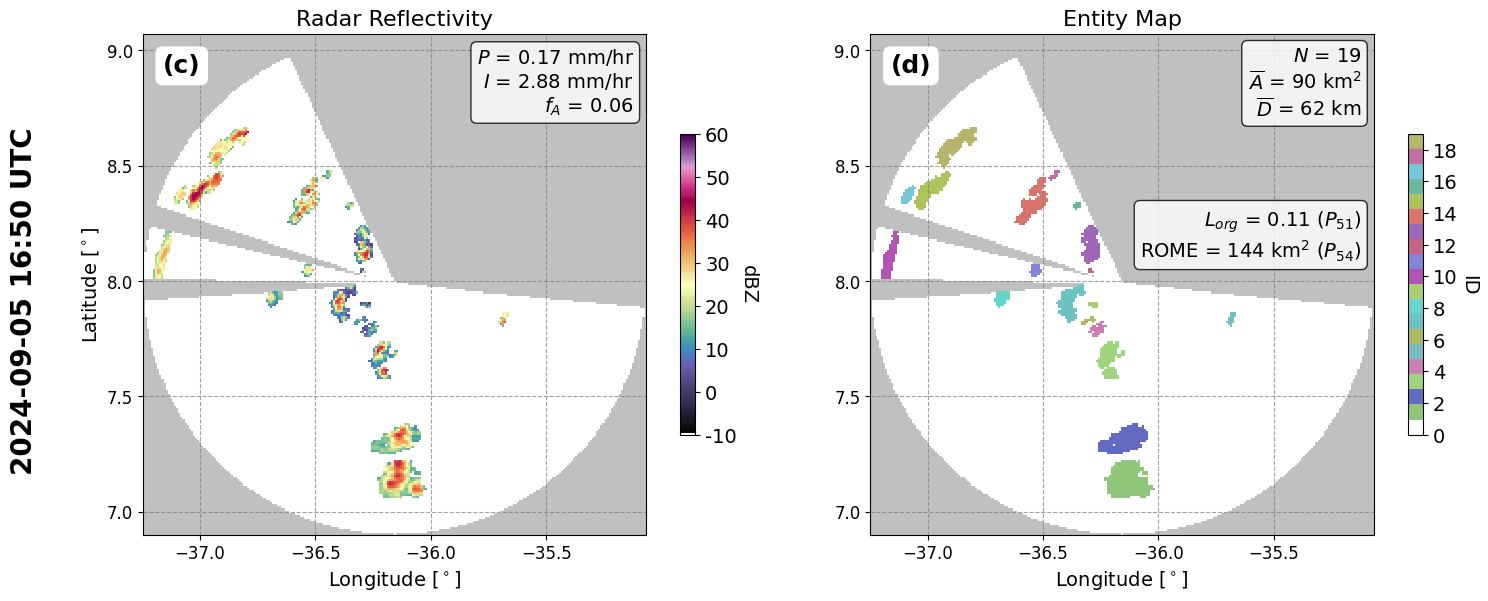

In [84]:
# Plots c and d (t = 4691 at 2024-09-105 16:50 UTC). 

# Set time and define color maps. 
t = 4691
time = scan_time[t]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Plot radar reflectivity map. 
ax = axes[0]
c = ax.pcolormesh(longitude_cropped[t,:,:], latitude_cropped[t,:,:], dbz_120km[t,start_idx:end_idx,start_idx:end_idx], cmap=cmap_dbz)
cbar = fig.colorbar(c, ax=ax, label='dBZ', shrink=0.6)
cbar.set_label('dBZ', rotation=270, labelpad=15, fontsize=14)
c.set_clim(-10, 60)
cbar.set_ticks(np.arange(-10, 70, 10))
cbar.set_ticklabels(np.arange(-10, 70, 10))
cbar.ax.tick_params(labelsize=14)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=14)
ax.set_ylabel('Latitude [$^\\circ$]', fontsize=14)
ax.grid(True, linestyle='--', color='gray', alpha=0.75)
ax.set_title('Radar Reflectivity', fontsize=16)
fig.text(
    -0.01, 0.475, f'{scan_time[t]} UTC',
    va='center', ha='left',
    fontsize=20, fontweight='bold',
    rotation='vertical'
)

# Annotate with precipitation metrics. 
precip_val = precip_all_120[t]
intensity_val = intensity_all_120[t]
fa_val = fa_all_120[t]
annotation_precip = (
    f"$P$ = {precip_val:.2f} mm/hr\n"
    f"$I$ = {intensity_val:.2f} mm/hr\n"
    f"$f_A$ = {fa_val:.2f}"
)
ax.text(
    0.975, 0.975, annotation_precip, transform=ax.transAxes,
    fontsize=14, verticalalignment='top', zorder=201,
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Plot the entity map using the helper function. 
dbz_array = dbz_120km[t,start_idx:end_idx,start_idx:end_idx]
plot_entity_map_all(axes[1], dbz_array, -30, np.inf, 'Entity Map')

# Styling. 
for ax in axes:
    lon_min = np.nanmin(longitude_cropped[t, :, :])
    lon_max = np.nanmax(longitude_cropped[t, :, :])
    lat_min = np.nanmin(latitude_cropped[t, :, :])
    lat_max = np.nanmax(latitude_cropped[t, :, :])
    lon_ticks = np.arange(np.floor(lon_min), np.ceil(lon_max) + 0.5, 0.5)
    lat_ticks = np.arange(np.floor(lat_min), np.ceil(lat_max) + 0.5, 0.5)
    ax.set_xticks(lon_ticks)
    ax.set_yticks(lat_ticks)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect('equal')

# Labeling. 
labels = ['(c)', '(d)']
for i, ax in enumerate(axes):
    ax.text(
        0.04, 0.96, labels[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left',
        zorder=300,
        bbox=dict(boxstyle='round', facecolor='white', alpha=1, edgecolor='none')
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

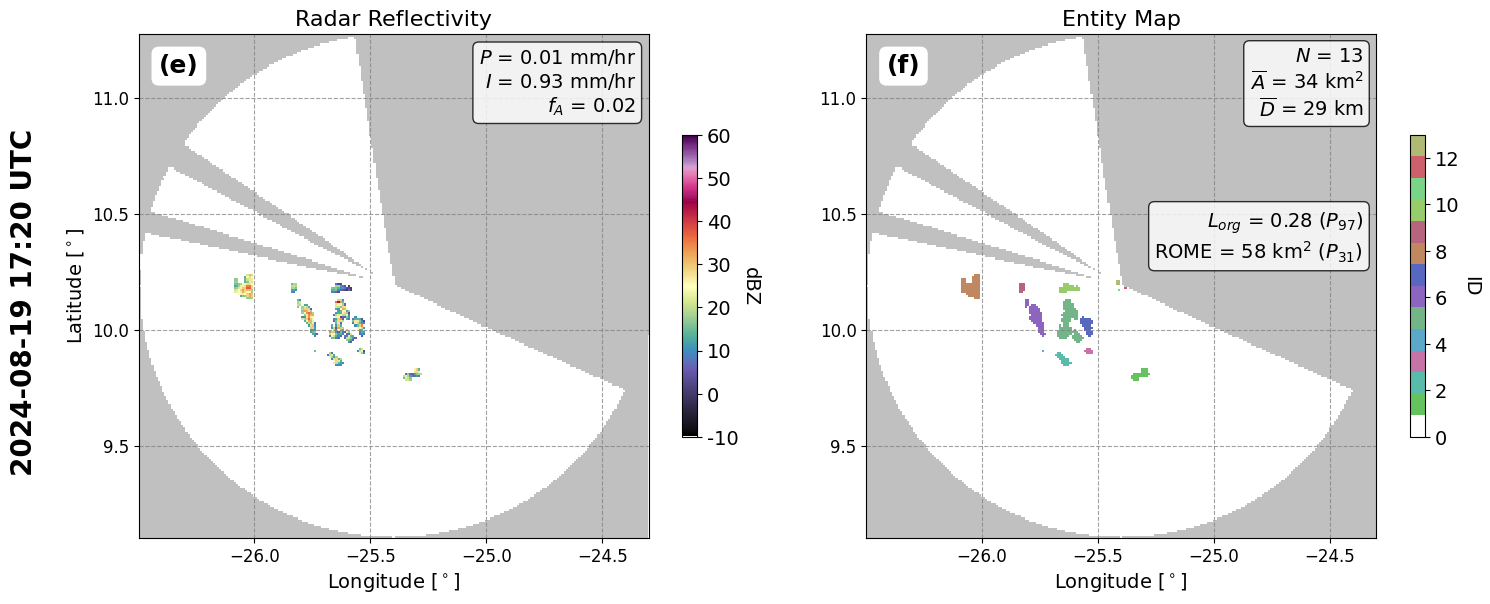

In [85]:
# Plots e and f (t = 836 at 2024-08-19 17:20 UTC). 

# Set time and define color maps. 
t = 836
time = scan_time[t]

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

# Plot radar reflectivity map. 
ax = axes[0]
c = ax.pcolormesh(longitude_cropped[t,:,:], latitude_cropped[t,:,:], dbz_120km[t,start_idx:end_idx,start_idx:end_idx], cmap=cmap_dbz)
cbar = fig.colorbar(c, ax=ax, label='dBZ', shrink=0.6)
cbar.set_label('dBZ', rotation=270, labelpad=15, fontsize=14)
c.set_clim(-10, 60)
cbar.set_ticks(np.arange(-10, 70, 10))
cbar.set_ticklabels(np.arange(-10, 70, 10))
cbar.ax.tick_params(labelsize=14)
ax.set_xlabel('Longitude [$^\\circ$]', fontsize=14)
ax.set_ylabel('Latitude [$^\\circ$]', fontsize=14)
ax.grid(True, linestyle='--', color='gray', alpha=0.75)
ax.set_title('Radar Reflectivity', fontsize=16)
fig.text(
    -0.01, 0.475, f'{scan_time[t]} UTC',
    va='center', ha='left',
    fontsize=20, fontweight='bold',
    rotation='vertical'
)

# Annotate with precipitation metrics. 
precip_val = precip_all_120[t]
intensity_val = intensity_all_120[t]
fa_val = fa_all_120[t]
annotation_precip = (
    f"$P$ = {precip_val:.2f} mm/hr\n"
    f"$I$ = {intensity_val:.2f} mm/hr\n"
    f"$f_A$ = {fa_val:.2f}"
)
ax.text(
    0.975, 0.975, annotation_precip, transform=ax.transAxes,
    fontsize=14, verticalalignment='top', zorder=201,
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

# Plot the entity map using the helper function. 
dbz_array = dbz_120km[t,start_idx:end_idx,start_idx:end_idx]
plot_entity_map_all(axes[1], dbz_array, -30, np.inf, 'Entity Map')

# Styling. 
for ax in axes:
    lon_min = np.nanmin(longitude_cropped[t, :, :])
    lon_max = np.nanmax(longitude_cropped[t, :, :])
    lat_min = np.nanmin(latitude_cropped[t, :, :])
    lat_max = np.nanmax(latitude_cropped[t, :, :])
    lon_ticks = np.arange(np.floor(lon_min), np.ceil(lon_max) + 0.5, 0.5)
    lat_ticks = np.arange(np.floor(lat_min), np.ceil(lat_max) + 0.5, 0.5)
    ax.set_xticks(lon_ticks)
    ax.set_yticks(lat_ticks)
    ax.tick_params(axis='both', labelsize=12)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect('equal')

# Labeling. 
labels = ['(e)', '(f)']
for i, ax in enumerate(axes):
    ax.text(
        0.04, 0.96, labels[i],
        transform=ax.transAxes,
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left',
        zorder=300,
        bbox=dict(boxstyle='round', facecolor='white', alpha=1, edgecolor='none')
    )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### ⚙️ Figure 8 (shortrange_lowpass_timeseries.png)

In [86]:
from scipy import signal
import numpy as np 
import matplotlib.pyplot as plt

# Set the hour times as the list of times used in computing the hourly mean of precipitation at short range. 
hour_times = precip_weighted_index_list_120

# Define a data frame with the hour times and the corresponding precipitation, intensity, and fa values. Set the time column as the index.
df_p = pd.DataFrame({'time': hour_times, 'p': precip_weighted_120, 'intensity': intensity_weighted_120, 'fa': fa_weighted_120})
df_p['time'] = pd.to_datetime(df_p['time'])
df_p.set_index('time', inplace=True)

# Interpolate across NaNs before filtering. 
p_interp = pd.Series(df_p['p']).interpolate(method='linear', limit_direction='both').values

# Set the sample frequency to one sample per hour. 
fs = 1.0      

# Set the cutoff period to 24 hours. 
cutoff_period = 24   # hours
fc = 1.0 / cutoff_period  # cycles per hour
nyq = 0.5 * fs
normal_cutoff = fc / nyq

# Design a Butterworth low-pass filter of the specified order and cutoff frequency.
order = 4
b_lp, a_lp = signal.butter(order, normal_cutoff, btype='low', analog=False)

# Precipitation low-pass and high-pass components with a 24 hour cutoff. 
precip_lp = signal.filtfilt(b_lp, a_lp, p_interp)
precip_hp = p_interp - precip_lp
lp_series = pd.Series(precip_lp, index=df_p.index)
hp_series = pd.Series(precip_hp, index=df_p.index)

# Intensity. 
intensity_interp = pd.Series(df_p['intensity']).interpolate(method='linear', limit_direction='both').values
intensity_lp = signal.filtfilt(b_lp, a_lp, intensity_interp)
intensity_hp = intensity_interp - intensity_lp
intensity_lp_series = pd.Series(intensity_lp, index=df_p.index)
intensity_hp_series = pd.Series(intensity_hp, index=df_p.index)

# fA. 
fa_interp = pd.Series(df_p['fa']).interpolate(method='linear', limit_direction='both').values
fa_lp = signal.filtfilt(b_lp, a_lp, fa_interp)
fa_hp = fa_interp - fa_lp
fa_lp_series = pd.Series(fa_lp, index=df_p.index)
fa_hp_series = pd.Series(fa_hp, index=df_p.index)

# Create a new data frame with the hour times and the corresponding values of n, abar, and dbar. Set the time column as the index.
df_p = pd.DataFrame({'time': hour_times, 'n': n_weighted_120, 'abar': abar_weighted_120, 'dbar': dbar_weighted_120})
df_p['time'] = pd.to_datetime(df_p['time'])
df_p.set_index('time', inplace=True)

# Interpolate across NaNs before filtering. 
n_interp = pd.Series(df_p['n']).interpolate(method='linear', limit_direction='both').values
abar_interp = pd.Series(df_p['abar']).interpolate(method='linear', limit_direction='both').values
dbar_interp = pd.Series(df_p['dbar']).interpolate(method='linear', limit_direction='both').values

# Use the same order and cutoff frequency as before. 
b_lp, a_lp = signal.butter(order, normal_cutoff, btype='low', analog=False)

# N, Abar, and Dbar low-pass components with a 24 hour cutoff.
n_lp = signal.filtfilt(b_lp, a_lp, n_interp)
abar_lp = signal.filtfilt(b_lp, a_lp, abar_interp)
dbar_lp = signal.filtfilt(b_lp, a_lp, dbar_interp)
n_lp_series = pd.Series(n_lp, index=df_p.index)
abar_lp_series = pd.Series(abar_lp, index=df_p.index)
dbar_lp_series = pd.Series(dbar_lp, index=df_p.index)

# Create a new data frame with the hour times and the corresponding values of Lorg and ROME. Set the time column as the index.
df_lr = pd.DataFrame({'time': hour_times, 'lorg': lorg_weighted_120, 'rome': rome_weighted_120})
df_lr['time'] = pd.to_datetime(df_lr['time'])
df_lr.set_index('time', inplace=True)

# Interpolate across NaNs before filtering.
lorg_interp = pd.Series(df_lr['lorg']).interpolate(method='linear', limit_direction='both').values
rome_interp = pd.Series(df_lr['rome']).interpolate(method='linear', limit_direction='both').values

# Use the same order and cutoff frequency as before.
lorg_lp_series = pd.Series(signal.filtfilt(b_lp, a_lp, lorg_interp), index=df_lr.index)
rome_lp_series = pd.Series(signal.filtfilt(b_lp, a_lp, rome_interp), index=df_lr.index)

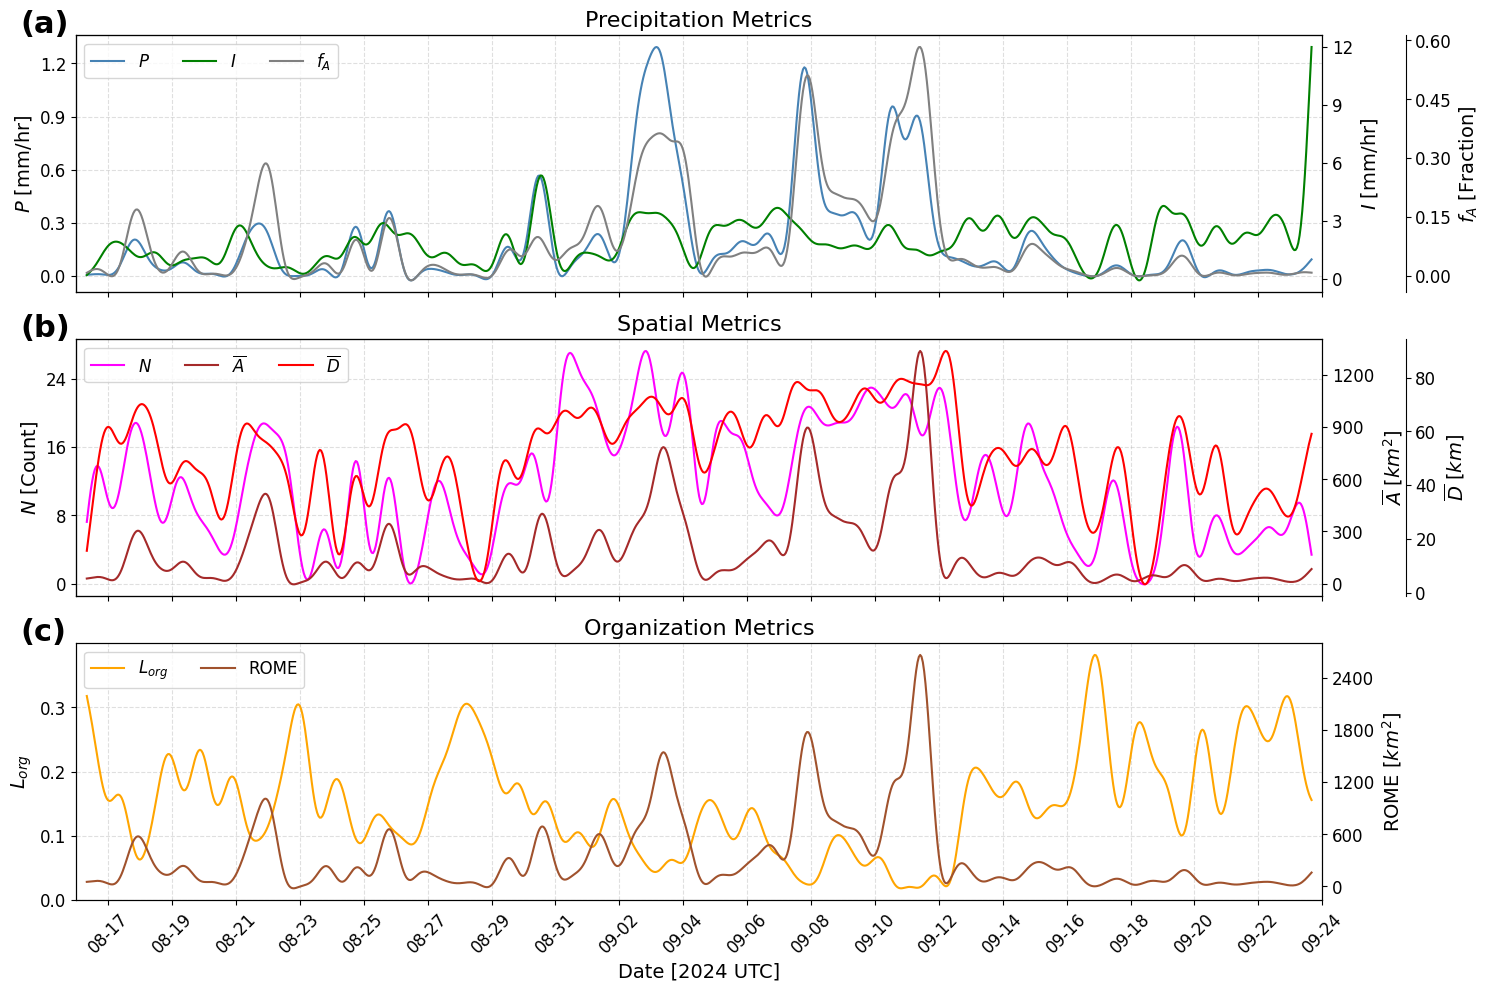

In [87]:
import matplotlib.dates as mdates
import pandas as pd
from scipy import signal
from matplotlib.ticker import MaxNLocator

# Show only between these dates. 
start = pd.to_datetime('2024-08-16')
end   = pd.to_datetime('2024-09-24')

# Helper function to slice between start and end. 
def between(s):
    return s.loc[start:end]

# Create a three-row subplot. 
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Top row has P, I, fA. 
ax = axes[0]
ax.plot(between(lp_series).index, between(lp_series).values, color='steelblue', linewidth=1.5, label='$P$')
ax.set_ylabel('$P$ [mm/hr]', fontsize = 14)
ax2 = ax.twinx()
ax2.plot(between(intensity_lp_series).index, between(intensity_lp_series).values, color='green', linewidth=1.5, label='$I$')
ax2.set_ylabel('$I$ [mm/hr]', fontsize = 14)
ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(between(fa_lp_series).index, between(fa_lp_series).values, color='gray', linewidth=1.5, label='$f_A$')
ax3.set_ylabel('$f_A$ [Fraction]', fontsize = 14)
lines, labels = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
l3, lb3 = ax3.get_legend_handles_labels()
ax.legend(lines + l2 + l3, labels + lb2 + lb3, loc='upper left', fontsize =12, ncol = 3)
ax.set_title('Precipitation Metrics', fontsize = 16)

# Middle row has N, Abar, Dbar. 
ax = axes[1]
ax.plot(between(n_lp_series).index, between(n_lp_series).values, color='magenta', linewidth=1.5, label='$N$')
ax.set_ylabel('$N$ [Count]', fontsize = 14)
ax2 = ax.twinx()
ax2.plot(between(abar_lp_series).index, between(abar_lp_series).values, color='brown', linewidth=1.5, label='$\\overline{A}$')
ax2.set_ylabel('$\\overline{A}$ [$km^2$]', fontsize = 14)
ax3 = ax.twinx()
ax3.spines['right'].set_position(('outward', 60))
ax3.plot(between(dbar_lp_series).index, between(dbar_lp_series).values, color='red', linewidth=1.5, label='$\\overline{D}$')
ax3.set_ylabel('$\\overline{D}$ [$km$]', fontsize = 14)
lines, labels = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
l3, lb3 = ax3.get_legend_handles_labels()
ax.legend(lines + l2 + l3, labels + lb2 + lb3, loc='upper left', fontsize =12, ncol = 3)
ax.set_title('Spatial Metrics', fontsize = 16)

# Bottom row has Lorg, ROME.
ax = axes[2]
ax.plot(between(lorg_lp_series).index, between(lorg_lp_series).values, color='orange', linewidth=1.5, label='$L_{org}$')
ax.set_ylabel('$L_{org}$', fontsize = 14)
ax2 = ax.twinx()
ax2.plot(between(rome_lp_series).index, between(rome_lp_series).values, color='sienna', linewidth=1.5, label='ROME')
ax2.set_ylabel('ROME [$km^2$]', fontsize = 14)
lines, labels = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(lines + l2, labels + lb2, loc='upper left',  fontsize=12, ncol = 2)
ax.set_title('Organization Metrics', fontsize = 16)

# Use MaxNLocator to give 4 y-ticks on all axes (including twins). 
for ax in fig.get_axes():
    # Create a new locator per axis.
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

# Force a redraw. 
fig.canvas.draw_idle()

# Set y tick labels fontsize for all axes (including twins). 
for a in fig.get_axes():
    plt.setp(a.get_yticklabels(), fontsize=12)

# Common x formatting and limits. 
axes[-1].xaxis.set_major_locator(mdates.DayLocator(interval=2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
axes[-1].set_xlabel('Date [2024 UTC]', fontsize=14)
plt.setp(axes[-1].get_xticklabels(), fontsize=12, rotation=45)
plt.xlim(start, end)
for a in axes:
    a.grid(alpha=0.4, linestyle='--')

# Add labels. 
for i, lbl in enumerate(['(a)', '(b)', '(c)']):
    ax = axes[i]
    ax.text(-0.045, 1.1, lbl, transform=ax.transAxes, fontsize=22, fontweight='bold',
            va='top', ha='left')

plt.tight_layout()
plt.show()


### 🧭 Figure 9 (lorg_rmax_maps.png)

In [ ]:
with open('filename', 'rb') as f: # Replace file name with lorg_pr.pkl
    ds = pickle.load(f)

lorg_pr = ds['lorg_value'] # Lorg'

print('Done with L-org`')

with open('filename', 'rb') as f: # Replace file name with lorg_dbpr.pkl
    ds = pickle.load(f)

lorg_dbpr = ds['lorg_value'] # Lorg'' 

print('Done with L-org``')

Done with L-org`
Done with L-org``


In [89]:
# Spatially subset radar data to within a specified radius from SEA-POL for specified time indicies. 

t = 4921

# Extract the t-th 2D slices (as numpy arrays)
rr_t = rr[t].values if hasattr(rr[t], "values") else np.array(rr[t])
dbz_t = dbz[t].values if hasattr(dbz[t], "values") else np.array(dbz[t])

# Apply the radius mask to the t-th slice
rr_120km[t] = np.where(radius_mask, rr_t, np.nan)
dbz_120km[t] = np.where(radius_mask, dbz_t, np.nan)

# Preserve original invalid markers (NaNs and -32768) within that t-th slice
rr_invalid_t = np.isnan(rr_t) | (rr_t == -32768)
dbz_invalid_t = np.isnan(dbz_t) | (dbz_t == -32768)
rr_120km[t][rr_invalid_t] = np.nan
dbz_120km[t][dbz_invalid_t] = np.nan

print("Done masking rainrate and reflectivity for t =", t)

t = 2126

# Extract the t-th 2D slices (as numpy arrays)
rr_t = rr[t].values if hasattr(rr[t], "values") else np.array(rr[t])
dbz_t = dbz[t].values if hasattr(dbz[t], "values") else np.array(dbz[t])

# Apply the radius mask to the t-th slice
rr_120km[t] = np.where(radius_mask, rr_t, np.nan)
dbz_120km[t] = np.where(radius_mask, dbz_t, np.nan)

# Preserve original invalid markers (NaNs and -32768) within that t-th slice
rr_invalid_t = np.isnan(rr_t) | (rr_t == -32768)
dbz_invalid_t = np.isnan(dbz_t) | (dbz_t == -32768)
rr_120km[t][rr_invalid_t] = np.nan
dbz_120km[t][dbz_invalid_t] = np.nan

print("Done masking rainrate and reflectivity for t =", t)

Done masking rainrate and reflectivity for t = 4921
Done masking rainrate and reflectivity for t = 2126


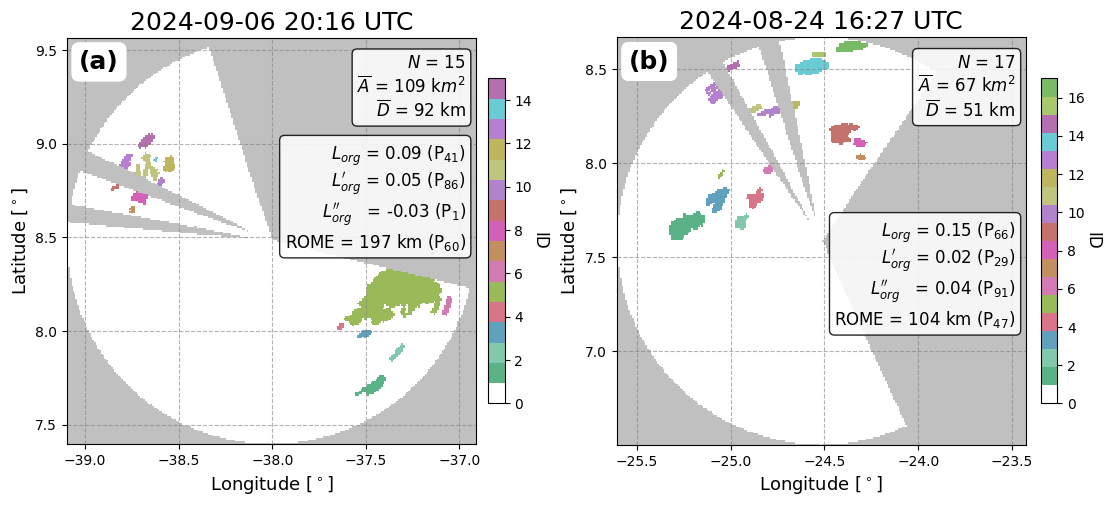

In [90]:
from scipy.ndimage import generate_binary_structure, label

# Set the time indices for the two entity map plots. 
t_list = [4921, 2126]
cluster_masks = []
num_clusters_list = []

# Define a helper function to create the cluster mask. 
def make_cluster_mask(t_entity):
    dbz_array = dbz_120km[t_entity, start_idx:end_idx, start_idx:end_idx]
    if not np.all(np.isnan(dbz_array)):
        rain_mask = np.where(np.isnan(dbz_array), 0,
                             np.where((dbz_array > -30) & (dbz_array <= 30000), 1, 0))
        s = generate_binary_structure(2, 2)
        cluster_mask, num_clusters = label(rain_mask, structure=s)
    else:
        cluster_mask = np.full_like(dbz_array, np.nan)
        num_clusters = 0

    # Create a mask for the scene with NaNs masked out. 
    rain_rate_array = rr_120km[t_entity, start_idx:end_idx, start_idx:end_idx]
    bad_mask = (
        (np.ma.is_masked(rain_rate_array) & np.ma.getmask(rain_rate_array))
        | np.isnan(rain_rate_array)
        | (rain_rate_array == '--')
        | (rain_rate_array == -32768)
    )
    cluster_mask = np.where(bad_mask, np.nan, cluster_mask).astype(float)
    return cluster_mask, int(np.nanmax(cluster_mask)) if np.isfinite(np.nanmax(cluster_mask)) else 0

# For each time index, create the cluster mask and store the number of clusters.
for t_entity in t_list:
    cm, nc = make_cluster_mask(t_entity)
    cluster_masks.append(cm)
    num_clusters_list.append(nc)

# Set up the figure. 
fig, axes = plt.subplots(1, 2, figsize=(11, 5.5), constrained_layout=True)

# Create a cluster mask and entity map for each time index. 
for ax, t_entity, cluster_mask, nc in zip(axes.ravel(), t_list, cluster_masks, num_clusters_list):

    # Set the color map. 
    color_list = ['#FFFFFF'] + [id_to_color(i) for i in range(1, nc + 1)]
    cmap_local = mcolors.ListedColormap(color_list)
    cmap_local.set_bad('silver')

    # Plot the entity map.
    im = ax.pcolormesh(
        longitude_cropped[t_entity, :, :],
        latitude_cropped[t_entity, :, :],
        cluster_mask,
        cmap=cmap_local,
        shading='auto',
        vmin=0,
        vmax=nc
    )

    # Labels. 
    ax.set_title(f'{scan_time[t_entity]} UTC', fontsize=18)
    ax.set_xlabel('Longitude [$^\\circ$]', fontsize=13)
    ax.set_ylabel('Latitude [$^\\circ$]', fontsize=13)
    ax.grid(True, linestyle='--', color='gray', alpha=0.6)

    # Compute percentiles of Lorg and ROME values for the scene. 
    lorg_nonan = np.array(lorg_all)[~np.isnan(lorg_all)]
    rome_nonan = np.array(rome_all_120)[~np.isnan(rome_all_120)]
    lorg_percentile = (np.sum(lorg_nonan < lorg_all[t_entity]) / len(lorg_nonan) * 100) if len(lorg_nonan) > 0 else np.nan
    rome_percentile = (np.sum(rome_nonan < rome_all_120[t_entity]) / len(rome_nonan) * 100) if len(rome_nonan) > 0 else np.nan

    # Compute Lorg' and Lorg'' values and percentiles for the scene.
    lorg_pr_val = lorg_pr[t_entity]
    lorg_dbpr_val   = lorg_dbpr[t_entity]
    lorg_pr_nonan = np.array(lorg_pr)[~np.isnan(lorg_pr)]
    lorg_dbpr_nonan   = np.array(lorg_dbpr)[~np.isnan(lorg_dbpr)]
    lorg_pr_percentile = (np.sum(lorg_pr_nonan < lorg_pr_val) / len(lorg_pr_nonan) * 100) if len(lorg_pr_nonan) > 0 else np.nan
    lorg_dbpr_percentile   = (np.sum(lorg_dbpr_nonan   < lorg_dbpr_val)   / len(lorg_dbpr_nonan)   * 100) if len(lorg_dbpr_nonan) > 0 else np.nan

    def _fmt_val(v, fmt="{:.2f}"):
        return fmt.format(v) if np.isfinite(v) else "NA"
    def _fmt_pct(p):
        return f"{int(round(p))}" if np.isfinite(p) else "NA"

    # Annotate with N, Abar, Dbar, Lorg, Lorg', Lorg'', and ROME values and percentiles.
    textstr1 = (
        f"$N$ = {n_all_120[t_entity]:.0f}\n"
        f"$\\overline{{A}}$ = {abar_all_120[t_entity]:.0f} k$m^2$\n"
        f"$\\overline{{D}}$ = {dbar_all_120[t_entity]:.0f} km"
    )
    textstr2 = (
        f"$L_{{org}}$ = {lorg_all[t_entity]:.2f} (P$_{{{_fmt_pct(lorg_percentile)}}}$)\n"
        f"$L_{{org}}'$ = {_fmt_val(lorg_pr_val)} (P$_{{{_fmt_pct(lorg_pr_percentile)}}}$)\n"
        f"$L_{{org}}''$   = {_fmt_val(lorg_dbpr_val)} (P$_{{{_fmt_pct(lorg_dbpr_percentile)}}}$)\n"
        f"ROME = {rome_all_120[t_entity]:.0f} km (P$_{{{_fmt_pct(rome_percentile)}}}$)"  
    )

    # Place text strings. 
    y_pos = 0.74 if ax is axes[0] else 0.55
    ax.text(
        0.975, y_pos, textstr2,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        zorder=201,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
    )

    ax.text(
        0.975, 0.96, textstr1,
        transform=ax.transAxes,
        fontsize=12,
        verticalalignment='top',
        horizontalalignment='right',
        zorder=201,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85)
    )

    # Set ticks. 
    lon_min = np.nanmin(longitude_cropped[t_entity, :, :])
    lon_max = np.nanmax(longitude_cropped[t_entity, :, :])
    lat_min = np.nanmin(latitude_cropped[t_entity, :, :])
    lat_max = np.nanmax(latitude_cropped[t_entity, :, :])
    lon_ticks = np.arange(np.floor(lon_min), np.ceil(lon_max) + 0.5, 0.5)
    lat_ticks = np.arange(np.floor(lat_min), np.ceil(lat_max) + 0.5, 0.5)
    ax.set_xticks(lon_ticks)
    ax.set_yticks(lat_ticks)
    ax.tick_params(axis='both', labelsize=10)
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect('equal')

    # Add subplot colorbar. 
    step = 2
    ticks = np.arange(0, nc + 1, step)
    cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
    cbar.set_label('ID', rotation=270, labelpad=12, fontsize=12)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([str(int(t)) for t in ticks], fontsize=10)

    # Add labels. 
    axes[0].text(
        0.03, 0.97, '(a)',
        transform=axes[0].transAxes,
        fontsize=18,
        fontweight='bold',
        verticalalignment='top',
        horizontalalignment='left',
        zorder=1000,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=1.0)
    )

    axes[1].text(
        0.03, 0.97, '(b)',
        transform=axes[1].transAxes,
        fontsize=18,
        fontweight='bold',
        verticalalignment='top',
        horizontalalignment='left',
        zorder=1000,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=1.0)
    )
plt.show()


### 📔 Figure 10 (spatialsubset_correlations.png)

In [ ]:
# Read in the precipitation metrics for the 60 km radial subset. 
metrics_ds = xr.open_dataset('filename') # Replace file name with precip_metrics_60km.nc

n_all_60 = metrics_ds['n_all_60'].values
abar_all_60 = metrics_ds['abar_all_60'].values
dbar_all_60 = metrics_ds['dbar_all_60'].values
precip_all_60 = metrics_ds['precip_all_60'].values
intensity_all_60 = metrics_ds['intensity_all_60'].values
fa_all_60 = metrics_ds['fa_all_60'].values
print('Done with loading 60 km metrics.')

# Read in the precipitation metrics for the 30 km radial subset. 
metrics_ds = xr.open_dataset('filename') # Replace file name with precip_metrics_30km.nc

n_all_30 = metrics_ds['n_all_30'].values
abar_all_30 = metrics_ds['abar_all_30'].values
dbar_all_30 = metrics_ds['dbar_all_30'].values
precip_all_30 = metrics_ds['precip_all_30'].values
intensity_all_30 = metrics_ds['intensity_all_30'].values
fa_all_30 = metrics_ds['fa_all_30'].values
print('Done with loading 30 km metrics.')

# Read in the precipitation metrics for the 15 km radial subset. 
metrics_ds = xr.open_dataset('filename') # Replace file name with precip_metrics_15km.nc

n_all_15 = metrics_ds['n_all_15'].values
abar_all_15 = metrics_ds['abar_all_15'].values
dbar_all_15 = metrics_ds['dbar_all_15'].values
precip_all_15 = metrics_ds['precip_all_15'].values
intensity_all_15 = metrics_ds['intensity_all_15'].values
fa_all_15 = metrics_ds['fa_all_15'].values
print('Done with loading 15 km metrics.')

# Read in the precipitation metrics for the 5 km radial subset. 
metrics_ds = xr.open_dataset('filename') # Replace file name with precip_metrics_5km.nc

n_all_5 = metrics_ds['n_all_5'].values
abar_all_5 = metrics_ds['abar_all_5'].values
dbar_all_5 = metrics_ds['dbar_all_5'].values
precip_all_5 = metrics_ds['precip_all_5'].values
intensity_all_5 = metrics_ds['intensity_all_5'].values
fa_all_5 = metrics_ds['fa_all_5'].values
print('Done with loading 5 km metrics.')

Done with loading 60 km metrics.
Done with loading 30 km metrics.
Done with loading 15 km metrics.
Done with loading 5 km metrics.


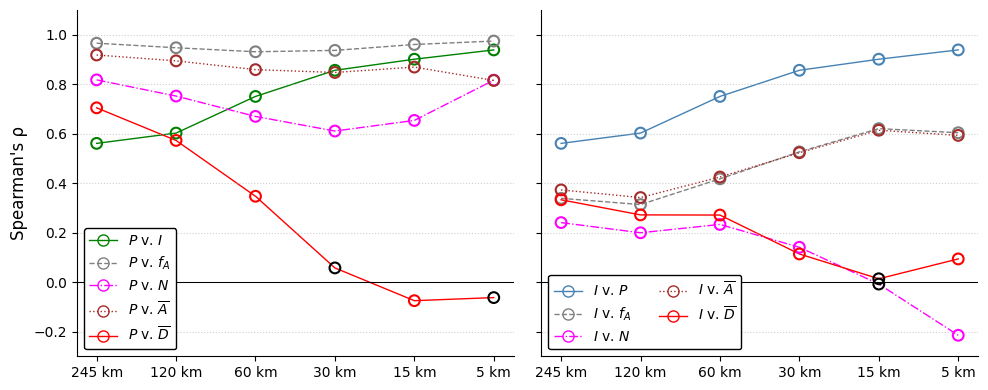

In [92]:
from matplotlib.lines import Line2D

# Create a list of the name of the radial distance and a dictionary of the corresponding metrics for each distance.
items = [
    ("245 km", dict(P=precip_245, I=intensity_245, fa=fa_245, N=n_245, abar=abar_245, dbar=dbar_245)),
    ("120 km", dict(P=precip_all_120, I=intensity_all_120, fa=fa_all_120, N=n_all_120, abar=abar_all_120, dbar=dbar_all_120)),
    ("60 km",  dict(P=precip_all_60,  I=intensity_all_60,  fa=fa_all_60,  N=n_all_60,  abar=abar_all_60,  dbar=dbar_all_60)),
    ("30 km",  dict(P=precip_all_30,  I=intensity_all_30,  fa=fa_all_30,  N=n_all_30,  abar=abar_all_30,  dbar=dbar_all_30)),
    ("15 km",  dict(P=precip_all_15,  I=intensity_all_15,  fa=fa_all_15,  N=n_all_15,  abar=abar_all_15,  dbar=dbar_all_15)),
    ("5 km",   dict(P=precip_all_5,   I=intensity_all_5,   fa=fa_all_5,   N=n_all_5,   abar=abar_all_5,   dbar=dbar_all_5)),
]

# Labels from the items list.
labels = [it[0] for it in items]

# Helper function to make a pandas Series from an array, and set the index to the standard time grid if the length matches.
def make_series(obj, name):
    s = pd.Series(obj).rename(name)
    try:
        if len(s) == len(standard_time_grid):
            s.index = pd.to_datetime(standard_time_grid)
    except Exception:
        pass
    return s

# Define the pairs of metrics to compute Spearman correlations for, along with labels for plotting.
pairs = [
    ('P','I','P vs I'),
    ('P','fa','P vs f_A'),
    ('P','N','P vs N'),
    ('P','abar','P vs Abar'),
    ('P','dbar','P vs dbar'),
]

# Prepare storage lists. 
rhos = {label: [] for _,_,label in pairs}
ps  = {label: [] for _,_,label in pairs}

# Compute the spearman rhos and p-values for each pair of metrics (v. P) across the different radial distances.
for lbl, d in items:
    series = {k: make_series(v, k) for k,v in d.items()}
    for a,b,label in pairs:
        sa = series.get(a); sb = series.get(b)
        if sa is None or sb is None:
            rhos[label].append(np.nan); ps[label].append(np.nan); continue
        df = pd.concat([sa, sb], axis=1).dropna()
        if len(df) >= 3:
            rho, p, _ = spearman_with_autocorr(df.iloc[:,0].values, df.iloc[:,1].values)
        else:
            rho, p = np.nan, np.nan
        rhos[label].append(rho); ps[label].append(p)

# Compute the spearman rhos and p-values for each pair of metrics (v. I) across the different radial distances.
pairs2 = [
    ('I','P','I vs P'),
    ('I','fa','I vs f_A'),
    ('I','N','I vs N'),
    ('I','abar','I vs Abar'),
    ('I','dbar','I vs dbar'),
]

rhos2 = {label: [] for _,_,label in pairs2}
ps2   = {label: [] for _,_,label in pairs2}

for lbl, d in items:
    series = {k: make_series(v, k) for k,v in d.items()}
    for a,b,label in pairs2:
        sa = series.get(a); sb = series.get(b)
        if sa is None or sb is None:
            rhos2[label].append(np.nan); ps2[label].append(np.nan); continue
        df = pd.concat([sa, sb], axis=1).dropna()
        if len(df) >= 3:
            rho, p, _ = spearman_with_autocorr(df.iloc[:,0].values, df.iloc[:,1].values)
        else:
            rho, p = np.nan, np.nan
        rhos2[label].append(rho); ps2[label].append(p)

# Create a figure with two subplots. 
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
fig.subplots_adjust(wspace=0.28)
x = np.arange(len(labels))

# Add labels and colors. 
plot_specs = [
    ('P vs I',  dict(marker='o', linestyle='-',  color='green')),
    ('P vs f_A',dict(marker='o', linestyle='--', color='gray')),
    ('P vs N',   dict(marker='o', linestyle='-.', color='magenta')),
    ('P vs Abar',dict(marker='o', linestyle=':',  color='brown')),
    ('P vs dbar',dict(marker='o', linestyle='-',  color='red')),
]

offsets = [0, 0, 0, 0, 0]

# Left subplot (pairs v. P). 
for i, (label, spec) in enumerate(plot_specs):
    y = np.array(rhos[label], dtype=float)
    pvals = np.array(ps[label], dtype=float)

    ax.plot(x, y, color=spec['color'], linestyle=spec.get('linestyle','-'), linewidth=1, zorder=1)

    for xi, yi, pv in zip(x, y, pvals):
        if np.isnan(yi):
            continue
        sig = False
        try:
            sig = (pv < 0.01)
        except Exception:
            sig = False

        y_plot = yi + (offsets[i] if i < len(offsets) else 0.0)

        if sig:
            ax.scatter(xi, y_plot, marker=spec['marker'], facecolor='none',
                       edgecolor=spec['color'],
                       s=60, linewidths=1.5, zorder=4)
        else: # Plot the point in black if not significant. 
            ax.scatter(xi, y_plot, marker=spec['marker'], facecolor='none', 
                       edgecolor='black',
                       alpha=1, s=60, linewidths=1.5, zorder=3)

# Styling. 
ax.axhline(0, color='black', linewidth=0.75, linestyle='-')
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=0)
ax.set_ylim(-0.3, 1.1)
ax.set_ylabel("Spearman's ρ", fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.6)

# Set labels. 
new_labels_left = [
    r"$P$ v. $I$",
    r"$P$ v. $f_A$",
    r"$P$ v. $N$",
    r"$P$ v. $\overline{A}$",
    r"$P$ v. $\overline{D}$",
]

# Create legend. 
legend_handles = []
for label, spec in plot_specs:
    handle = Line2D([0], [0], marker=spec['marker'],
                    markeredgecolor=spec['color'],
                    markerfacecolor='none',
                    color=spec['color'],
                    linestyle=spec.get('linestyle','-'),
                    markersize=8, linewidth=1)
    legend_handles.append(handle)
ax.legend(legend_handles, new_labels_left, loc='lower left',
           framealpha=1, facecolor='white', edgecolor='black')

# Left subplot (pairs v. I). 
plot_specs2 = [
    ('I vs P', dict(marker='o', linestyle='-', color='steelblue')),
    ('I vs f_A', dict(marker='o', linestyle='--', color='gray')),
    ('I vs N',   dict(marker='o', linestyle='-.', color='magenta')),
    ('I vs Abar',dict(marker='o', linestyle=':',  color='brown')),
    ('I vs dbar',dict(marker='o', linestyle='-',  color='red')),
]

for i, (label, spec) in enumerate(plot_specs2):
    y = np.array(rhos2[label], dtype=float)
    pvals = np.array(ps2[label], dtype=float)

    ax2.plot(x, y, color=spec['color'], linestyle=spec.get('linestyle','-'), linewidth=1, zorder=1)

    for xi, yi, pv in zip(x, y, pvals):
        if np.isnan(yi):
            continue
        sig = False
        try:
            sig = (pv < 0.01)
        except Exception:
            sig = False

        y_plot = yi

        if sig:
            ax2.scatter(xi, y_plot, marker=spec['marker'], facecolor='none',
                       edgecolor=spec['color'],
                       s=60, linewidths=1.5, zorder=4)
        else:
            ax2.scatter(xi, y_plot, marker=spec['marker'], facecolor='none',
                       edgecolor='black',
                       alpha=1, s=60, linewidths=1.5, zorder=3)

# Styling. 
ax2.axhline(0, color='black', linewidth=0.75, linestyle='-')
ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=0)
ax2.set_ylim(ax.get_ylim())
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', linestyle=':', alpha=0.6)

# Labels. 
new_labels_right = [
    r"$I$ v. $P$",
    r"$I$ v. $f_A$",
    r"$I$ v. $N$",
    r"$I$ v. $\overline{A}$",
    r"$I$ v. $\overline{D}$",
]

# Create legend. 
legend_handles = []
for label, spec in plot_specs2:
    handle = Line2D([0], [0], marker=spec['marker'],
                    markeredgecolor=spec['color'],
                    markerfacecolor='none',
                    color=spec['color'],
                    linestyle=spec.get('linestyle','-'),
                    markersize=8, linewidth=1)
    legend_handles.append(handle)
ax2.legend(legend_handles, new_labels_right, loc='lower left',
           framealpha=1, facecolor='white', edgecolor='black', ncol = 2)

plt.setp(ax2.get_yticklabels(), visible=False)
plt.tight_layout()
plt.show()